<a href="https://colab.research.google.com/github/arielabade/carbon/blob/main/graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

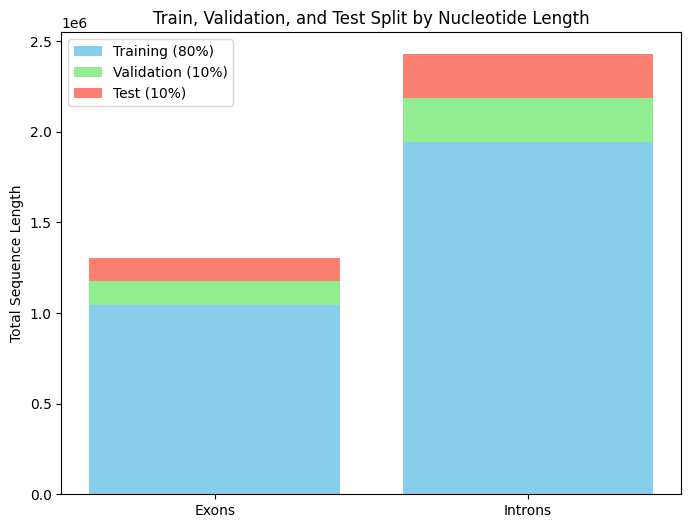

In [1]:
import matplotlib.pyplot as plt

# Total data
total_exons = 4021
total_introns = 3965
total_exon_length = 1305306
total_intron_length = 2427045

# Percentages for train, validation, and test
train_percentage = 0.80
val_percentage = 0.10
test_percentage = 0.10

# Split calculation for exons and introns
train_exons = total_exons * train_percentage
val_exons = total_exons * val_percentage
test_exons = total_exons * test_percentage

train_introns = total_introns * train_percentage
val_introns = total_introns * val_percentage
test_introns = total_introns * test_percentage

# Split calculation for exon and intron sizes
train_exon_length = total_exon_length * train_percentage
val_exon_length = total_exon_length * val_percentage
test_exon_length = total_exon_length * test_percentage

train_intron_length = total_intron_length * train_percentage
val_intron_length = total_intron_length * val_percentage
test_intron_length = total_intron_length * test_percentage

# Stacked bar chart for visualization
labels = ['Exons', 'Introns']
train = [train_exon_length, train_intron_length]
val = [val_exon_length, val_intron_length]
test = [test_exon_length, test_intron_length]

# Create chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(labels, train, label='Training (80%)', color='skyblue')
ax.bar(labels, val, bottom=train, label='Validation (10%)', color='lightgreen')
ax.bar(labels, test, bottom=[i + j for i, j in zip(train, val)], label='Test (10%)', color='salmon')

# Add labels and title
ax.set_ylabel('Total Sequence Length')
ax.set_title('Train, Validation, and Test Split by Nucleotide Length')
ax.legend()

# Show chart
plt.show()


In [ ]:
!pip install tensorflow

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 32s 6s/step - accuracy: 0.5745 - loss: 0.6902 - val_accuracy: 0.4667 - val_loss: 0.6871
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.5641 - loss: 0.6768 - val_accuracy: 0.4667 - val_loss: 0.6797
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.5588 - loss: 0.6619 - val_accuracy: 0.4667 - val_loss: 0.6678
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.5745 - loss: 0.6377 - val_accuracy: 0.4667 - val_loss: 0.6490
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5816 - loss: 0.6154 - val_accuracy: 0.6000 - val_loss: 0.6114
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6342 - loss: 0.5595 - val_accuracy: 0.6000 - val_loss: 0.5614
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.7036 - loss: 0.5163 - val_accuracy: 0.9333 - val_loss: 0.5028
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.8786 - loss: 0.4566 - val_accuracy: 0.9333 - val_loss: 0.4464
Epoch

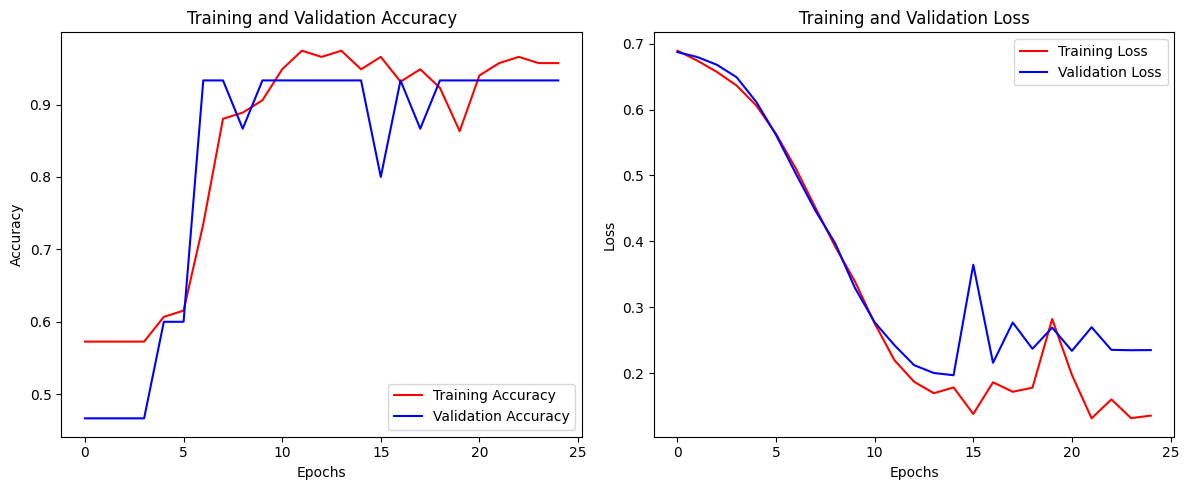

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# 1. Carregar múltiplos CSVs e concatená-los
file_paths = [
    "/content/GADPH_test_CORRECTED.csv",
]

dfs = [pd.read_csv(file) for file in file_paths]
df = pd.concat(dfs, ignore_index=True)

sequences = df['sequence'].values
labels = df['exon_intron_flag'].values

# 2. Tokenização das sequências
tokenizer = Tokenizer(char_level=True)  # Considera cada base (A, T, C, G) como uma unidade
tokenizer.fit_on_texts(sequences)
encoded_sequences = tokenizer.texts_to_sequences(sequences)

# 3. Padronizar o comprimento das sequências
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# 4. Divisão em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 5. Construção da RNN Bidirecional
vocab_size = len(tokenizer.word_index) + 1  # Inclui espaço para o índice 0
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. EarlyStopping para parar o treinamento se não houver melhoria na validação
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 7. Treinamento do modelo e coleta do histórico
history = model.fit(X_train, y_train, epochs=200, batch_size=64,
                    validation_data=(X_val, y_val), callbacks=[early_stopping])

# 8. Avaliação do modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Acurácia no conjunto de teste: {accuracy*100:.2f}%')

# 9. Fazendo predições com novos dados (se necessário)
new_data = pd.read_csv('/content/GADPH_test_CORRECTED.csv')
new_sequences = new_data['sequence'].values

# Tokenizar e padronizar
encoded_new_sequences = tokenizer.texts_to_sequences(new_sequences)
padded_new_sequences = pad_sequences(encoded_new_sequences, maxlen=max_len, padding='post')

# Fazer predições
predictions = model.predict(padded_new_sequences)
print(f'Predições para novas sequências: {predictions}')

# 10. Gerar o gráfico de overfitting (acurácia e perda)
plt.figure(figsize=(12, 5))

# Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Mostrar os gráficos
plt.tight_layout()
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.5901 - loss: 0.6906 - val_accuracy: 0.4667 - val_loss: 0.6900
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5693 - loss: 0.6805 - val_accuracy: 0.4667 - val_loss: 0.6861
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.5849 - loss: 0.6684 - val_accuracy: 0.4667 - val_loss: 0.6815
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6109 - loss: 0.6498 - val_accuracy: 0.4667 - val_loss: 0.6737
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5484 - loss: 0.6531 - val_accuracy: 0.4667 - val_loss: 0.6552
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.5759 - loss: 0.6274 - val_accuracy: 0.6000 - val_loss: 0.6288
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6134 - loss: 0.5916 - val_accuracy: 0.6000 - val_loss: 0.5911
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.6092 - loss: 0.5547 - val_accuracy: 0.7333 - val_loss: 0.5420
Epo

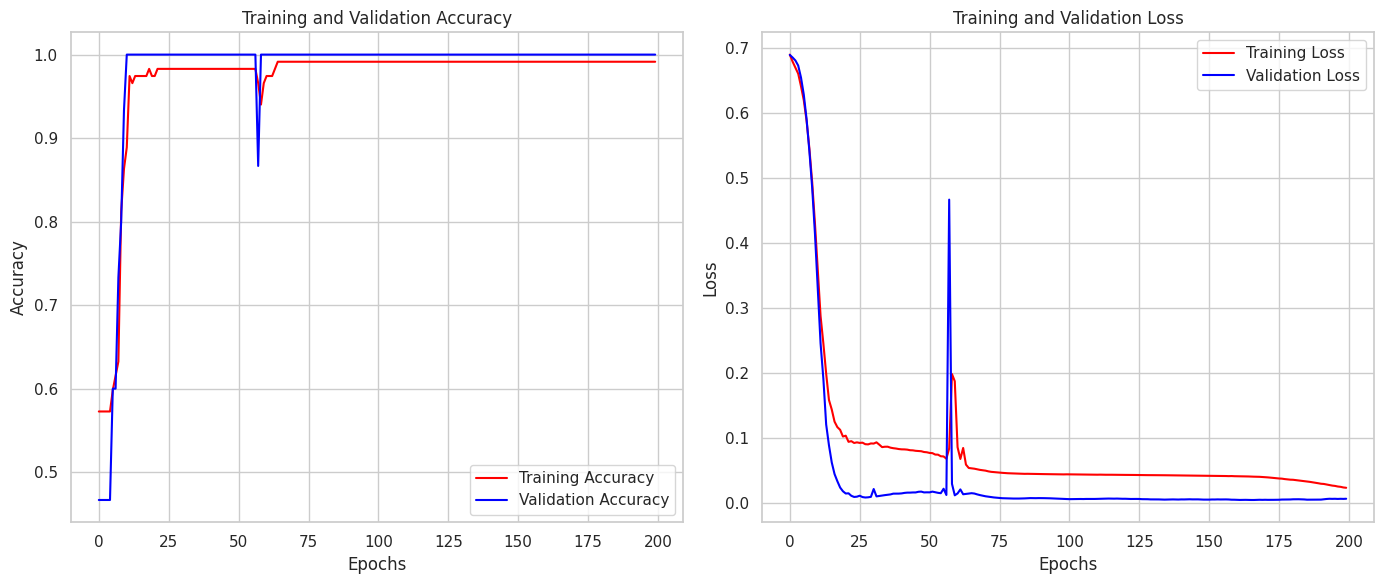

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

# 1. Carregar múltiplos CSVs e concatená-los
file_paths = [
    "/content/GADPH_test_CORRECTED.csv",
]

dfs = [pd.read_csv(file) for file in file_paths]
df = pd.concat(dfs, ignore_index=True)

sequences = df['sequence'].values
labels = df['exon_intron_flag'].values

# 2. Tokenização das sequências
tokenizer = Tokenizer(char_level=True)  # Considera cada base (A, T, C, G) como uma unidade
tokenizer.fit_on_texts(sequences)
encoded_sequences = tokenizer.texts_to_sequences(sequences)

# 3. Padronizar o comprimento das sequências
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# 4. Divisão em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 5. Construção da RNN Bidirecional
vocab_size = len(tokenizer.word_index) + 1  # Inclui espaço para o índice 0
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Treinamento do modelo e coleta do histórico (Sem EarlyStopping)
history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_data=(X_val, y_val))

# 7. Avaliação do modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Acurácia no conjunto de teste: {accuracy*100:.2f}%')

# 8. Fazendo predições com novos dados (se necessário)
new_data = pd.read_csv('/content/GADPH_test_CORRECTED.csv')
new_sequences = new_data['sequence'].values

# Tokenizar e padronizar
encoded_new_sequences = tokenizer.texts_to_sequences(new_sequences)
padded_new_sequences = pad_sequences(encoded_new_sequences, maxlen=max_len, padding='post')

# Fazer predições
predictions = model.predict(padded_new_sequences)
print(f'Predições para novas sequências: {predictions}')

# 9. Gerar gráficos com Seaborn
sns.set(style="whitegrid")

# Configurar figura
plt.figure(figsize=(14, 6))

# Subplot 1: Acurácia de Treinamento vs Validação
plt.subplot(1, 2, 1)
sns.lineplot(x=range(len(history.history['accuracy'])), y=history.history['accuracy'], label='Training Accuracy', color='red')
sns.lineplot(x=range(len(history.history['val_accuracy'])), y=history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Subplot 2: Perda de Treinamento vs Validação
plt.subplot(1, 2, 2)
sns.lineplot(x=range(len(history.history['loss'])), y=history.history['loss'], label='Training Loss', color='red')
sns.lineplot(x=range(len(history.history['val_loss'])), y=history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Ajustar layout e mostrar os gráficos
plt.tight_layout()
plt.show()


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.6290 - loss: 0.6913 - val_accuracy: 0.6000 - val_loss: 0.6884
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step - accuracy: 0.6290 - loss: 0.6823 - val_accuracy: 0.6000 - val_loss: 0.6819
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.5925 - loss: 0.6750 - val_accuracy: 0.6000 - val_loss: 0.6704
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6134 - loss: 0.6581 - val_accuracy: 0.6000 - val_loss: 0.6565
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.5978 - loss: 0.6418 - val_accuracy: 0.6000 - val_loss: 0.6331
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.6082 - loss: 0.6110 - val_accuracy: 0.6000 - val_loss: 0.5953
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.6542 - loss: 0.5729 - val_accuracy: 0.8000 - val_loss: 0.5381
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8572 - loss: 0.5142 - val_accuracy: 0.9333 - val_loss: 0.4665
Epoch 9/200
2/2 

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 524ms/step
Predições para novas sequências: [[9.9975210e-01]
 [9.9988765e-01]
 [8.3367944e-05]
 [9.9980778e-01]
 [9.9988765e-01]
 [9.9979258e-01]
 [9.9952215e-01]
 [9.9944800e-01]
 [9.9981934e-01]
 [9.9987555e-01]
 [9.9988854e-01]
 [9.9940830e-01]
 [8.3367944e-05]
 [3.7963942e-05]
 [2.9311204e-05]
 [7.5737087e-05]
 [7.0743692e-05]
 [5.6179771e-05]
 [3.3155599e-04]
 [1.5017040e-04]
 [9.9971366e-01]
 [9.9988765e-01]
 [9.9979258e-01]
 [9.9952215e-01]
 [9.9944800e-01]
 [9.9981934e-01]
 [9.9987555e-01]
 [9.9988854e-01]
 [9.9940825e-01]
 [8.3367944e-05]
 [3.7963942e-05]
 [2.9311233e-05]
 [9.4116706e-04]
 [7.0743692e-05]
 [5.6179771e-05]
 [3.3155599e-04]
 [1.5017040e-04]
 [9.9957132e-01]
 [9.9988765e-01]
 [9.9979258e-01]
 [9.9952215e-01]
 [9.9944800e-01]
 [9.9981934e-01]
 [9.9987555e-01]
 [9.9988854e-01]
 [8.3367944e-05]
 [3.8815171e-02]
 [2.9311204e-05]
 [7.5737087e-05]
 [7.0743692e-05]
 [5.6179771e-05]
 [3.3155599e-04]
 [9.9985224e-01]
 [9.9988765e-01]
 [9.997925

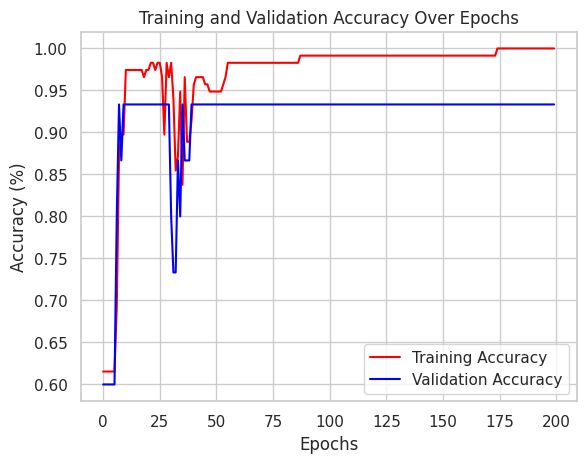

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

# 1. Carregar múltiplos CSVs e concatená-los
file_paths = [
    "/content/GADPH_test_CORRECTED.csv",
]

dfs = [pd.read_csv(file) for file in file_paths]
df = pd.concat(dfs, ignore_index=True)

sequences = df['sequence'].values
labels = df['exon_intron_flag'].values

# 2. Tokenização das sequências
tokenizer = Tokenizer(char_level=True)  # Considera cada base (A, T, C, G) como uma unidade
tokenizer.fit_on_texts(sequences)
encoded_sequences = tokenizer.texts_to_sequences(sequences)

# 3. Padronizar o comprimento das sequências
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# 4. Divisão em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 5. Construção da RNN Bidirecional
vocab_size = len(tokenizer.word_index) + 1  # Inclui espaço para o índice 0
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Treinamento do modelo e coleta do histórico
history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_data=(X_val, y_val))

# 7. Avaliação do modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Acurácia no conjunto de teste: {accuracy*100:.2f}%')

# 8. Fazendo predições com novos dados (se necessário)
new_data = pd.read_csv('/content/GADPH_test_CORRECTED.csv')
new_sequences = new_data['sequence'].values

# Tokenizar e padronizar
encoded_new_sequences = tokenizer.texts_to_sequences(new_sequences)
padded_new_sequences = pad_sequences(encoded_new_sequences, maxlen=max_len, padding='post')

# Fazer predições
predictions = model.predict(padded_new_sequences)
print(f'Predições para novas sequências: {predictions}')

# 9. Gerar o gráfico de overfitting
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalizar o gráfico
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Mostrar o gráfico
plt.show()


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.5470 - loss: 0.6911 - val_accuracy: 0.5714 - val_loss: 0.6819
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.5626 - loss: 0.6784 - val_accuracy: 0.5714 - val_loss: 0.6724
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.5802 - loss: 0.6655 - val_accuracy: 0.5714 - val_loss: 0.6615
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.6025 - loss: 0.6534 - val_accuracy: 0.5714 - val_loss: 0.6456
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.6181 - loss: 0.6235 - val_accuracy: 0.5714 - val_loss: 0.6215
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.6337 - loss: 0.5893 - val_accuracy: 0.6429 - val_loss: 0.5833
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.7102 - loss: 0.5568 - val_accuracy: 0.7857 - val_loss: 0.5349
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.9061 - loss: 0.4908 - val_accuracy: 0.7857 - val_loss: 0.4797
Epoch 9/200
2/2 

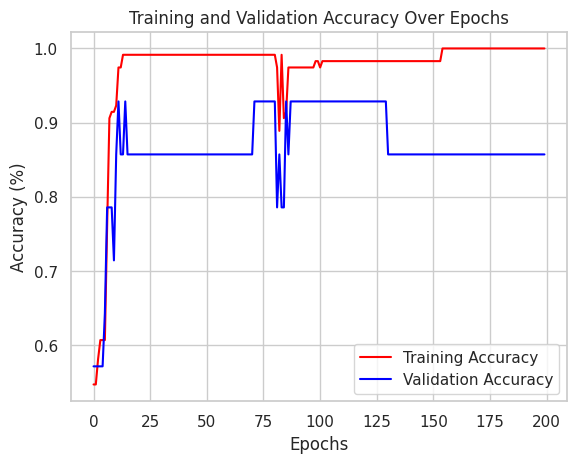

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

# 1. Carregar múltiplos CSVs e concatená-los
file_paths = [
    "/content/GADPH_test_CORRECTED.csv",
]

dfs = [pd.read_csv(file) for file in file_paths]
df = pd.concat(dfs, ignore_index=True)

sequences = df['sequence'].values
labels = df['exon_intron_flag'].values

# 2. Tokenização das sequências
tokenizer = Tokenizer(char_level=True)  # Considera cada base (A, T, C, G) como uma unidade
tokenizer.fit_on_texts(sequences)
encoded_sequences = tokenizer.texts_to_sequences(sequences)

# 3. Padronizar o comprimento das sequências
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# 4. Divisão fixa em treino (80%), validação (10%) e teste (10%)
total_samples = len(padded_sequences)
train_size = int(total_samples * 0.8)
val_size = int(total_samples * 0.1)

X_train = padded_sequences[:train_size]
y_train = labels[:train_size]

X_val = padded_sequences[train_size:train_size+val_size]
y_val = labels[train_size:train_size+val_size]

X_test = padded_sequences[train_size+val_size:]
y_test = labels[train_size+val_size:]

# 5. Construção da RNN Bidirecional
vocab_size = len(tokenizer.word_index) + 1  # Inclui espaço para o índice 0
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Treinamento do modelo e coleta do histórico
history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_data=(X_val, y_val))

# 7. Avaliação do modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Acurácia no conjunto de teste: {accuracy*100:.2f}%')

# 8. Fazendo predições com novos dados (se necessário)
new_data = pd.read_csv('/content/GADPH_test_CORRECTED.csv')
new_sequences = new_data['sequence'].values

# Tokenizar e padronizar
encoded_new_sequences = tokenizer.texts_to_sequences(new_sequences)
padded_new_sequences = pad_sequences(encoded_new_sequences, maxlen=max_len, padding='post')

# Fazer predições
predictions = model.predict(padded_new_sequences)
print(f'Predições para novas sequências: {predictions}')

# 9. Gerar o gráfico de overfitting
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalizar o gráfico
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Mostrar o gráfico
plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step - accuracy: 0.4074 - loss: 0.6937 - val_accuracy: 0.6667 - val_loss: 0.6868
Epoch 2/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.5741 - loss: 0.6900 - val_accuracy: 0.6667 - val_loss: 0.6797
Epoch 3/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.5741 - loss: 0.6860 - val_accuracy: 0.6667 - val_loss: 0.6726
Epoch 4/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.5741 - loss: 0.6822 - val_accuracy: 0.6667 - val_loss: 0.6650
Epoch 5/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.5741 - loss: 0.6782 - val_accuracy: 0.6667 - val_loss: 0.6575
Epoch 6/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 0.5741 - loss: 0.6744 - val_accuracy: 0.6667 - val_loss: 0.6500
Epoch 7/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.5741 - loss: 0.6703 - val_accuracy: 0.6667 - val_loss: 0.6429
Epoch 8/180
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5741 - loss: 0.6656 - val_accuracy: 0.6667 - val_loss:

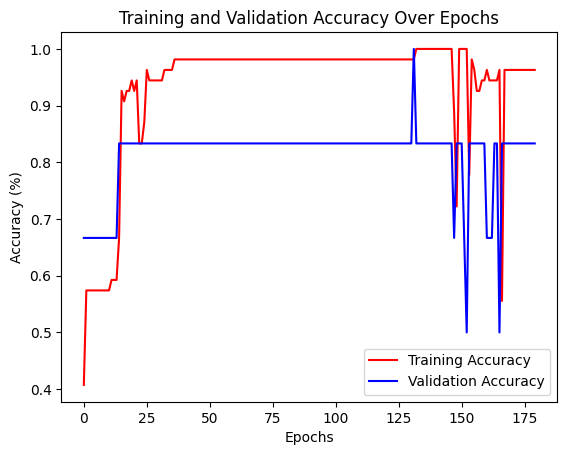

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense

# 1. Carregar múltiplos CSVs e concatená-los
file_paths = [

    "/content/B2MFIX_test_CORRECTED.csv",

]

dfs = [pd.read_csv(file) for file in file_paths]
df = pd.concat(dfs, ignore_index=True)

sequences = df['sequence'].values
labels = df['exon_intron_flag'].values

# 2. Tokenização das sequências
tokenizer = Tokenizer(char_level=True)  # Considera cada base (A, T, C, G) como uma unidade
tokenizer.fit_on_texts(sequences)
encoded_sequences = tokenizer.texts_to_sequences(sequences)

# 3. Padronizar o comprimento das sequências
max_len = max(len(seq) for seq in encoded_sequences)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# 4. Divisão fixa em treino (80%), validação (10%) e teste (10%)
total_samples = len(padded_sequences)
train_size = int(total_samples * 0.8)
val_size = int(total_samples * 0.1)

X_train = padded_sequences[:train_size]
y_train = labels[:train_size]

X_val = padded_sequences[train_size:train_size+val_size]
y_val = labels[train_size:train_size+val_size]

X_test = padded_sequences[train_size+val_size:]
y_test = labels[train_size+val_size:]

# 5. Construção da RNN Bidirecional
vocab_size = len(tokenizer.word_index) + 1  # Inclui espaço para o índice 0
embedding_dim = 64

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Treinamento do modelo e coleta do histórico
history = model.fit(X_train, y_train, epochs=180, batch_size=64, validation_data=(X_val, y_val))

# 7. Avaliação do modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Acurácia no conjunto de teste: {accuracy*100:.2f}%')

# 8. Fazendo predições com novos dados (se necessário)
new_data = pd.read_csv('/content/GADPH_test_CORRECTED.csv')
new_sequences = new_data['sequence'].values

# Tokenizar e padronizar
encoded_new_sequences = tokenizer.texts_to_sequences(new_sequences)
padded_new_sequences = pad_sequences(encoded_new_sequences, maxlen=max_len, padding='post')

# Fazer predições
predictions = model.predict(padded_new_sequences)
print(f'Predições para novas sequências: {predictions}')

# 9. Gerar o gráfico de overfitting
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalizar o gráfico
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Mostrar o gráfico
plt.show()


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.8545 - loss: 0.6927 - val_accuracy: 1.0000 - val_loss: 0.6829
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 0.6830 - val_accuracy: 1.0000 - val_loss: 0.6717
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6711 - val_accuracy: 1.0000 - val_loss: 0.6582
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6567 - val_accuracy: 1.0000 - val_loss: 0.6436
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6412 - val_accuracy: 1.0000 - val_loss: 0.6280
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 0.6245 - val_accuracy: 1.0000 - val_loss: 0.6115
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.6069 - val_accuracy: 1.0000 - val_loss: 0.5948
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.5891 - val_accuracy: 1.0000 - val_loss: 0.5785
Epoch 9/200
1/1 ━━

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


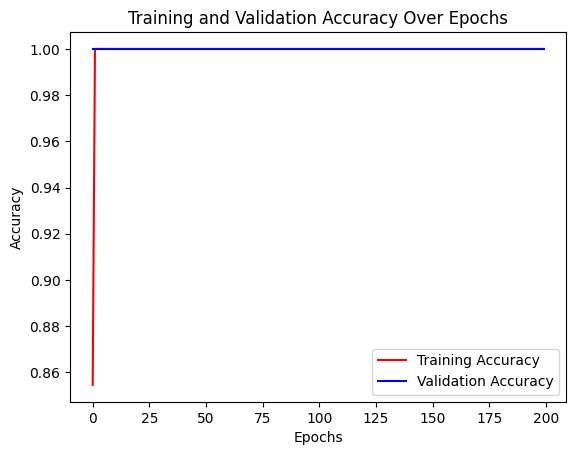

Validation Set: 0.00% Exons, 100.00% Introns
Test Set: 0.00% Exons, 100.00% Introns


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
max_len_limit = 1000  # Limite do tamanho máximo das sequências
batch_size = 64  # Tamanho do lote
epochs = 200  # Número de épocas para o treinamento

# 1. Função para carregar os dados dos arquivos CSV
def load_data(file_path):
    df = pd.read_csv(file_path)
    sequences = df['sequence'].values
    labels = df['exon_intron_flag'].values
    # Garantir que os rótulos sejam convertidos corretamente para 0 e 1
    labels = np.where(labels == 'exon', 1, 0)
    return sequences, labels

# 2. Tokenizar e Preencher Sequências
def preprocess_sequences(sequences, tokenizer, max_len):
    encoded_sequences = tokenizer.texts_to_sequences(sequences)
    padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
    return padded_sequences

# Carregar os dados dos arquivos CSV
train_sequences, train_labels = load_data('B2Mtrain_data.csv')
val_sequences, val_labels = load_data('B2Mval_data.csv')
test_sequences, test_labels = load_data('B2Mtest_data.csv')

# Tokenização
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(train_sequences)

# Calcular o tamanho máximo das sequências com base no conjunto de treino
max_len = min(max(len(seq) for seq in tokenizer.texts_to_sequences(train_sequences)), max_len_limit)

# Pré-processar as sequências (tokenização + padding)
X_train = preprocess_sequences(train_sequences, tokenizer, max_len)
X_val = preprocess_sequences(val_sequences, tokenizer, max_len)
X_test = preprocess_sequences(test_sequences, tokenizer, max_len)

# Converter rótulos para arrays NumPy
y_train = np.array(train_labels, dtype=np.int8)
y_val = np.array(val_labels, dtype=np.int8)
y_test = np.array(test_labels, dtype=np.int8)

# 3. Criar a Rede Neural BiLSTM
vocab_size = len(tokenizer.word_index) + 1  # Adicionar espaço para o índice de padding
embedding_dim = 16  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(8, return_sequences=True)),  # Reduzido de 16 para 8
    Bidirectional(LSTM(8)),  # Reduzido de 16 para 8
    Dense(16, activation='relu'),  # Reduzido de 32 para 16
    Dense(1, activation='sigmoid')  # Saída binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Classe do Gerador de Dados
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Criar os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 5. Treinar o modelo
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 6. Avaliar o modelo no conjunto de teste
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 7. Avaliar o modelo no conjunto de teste
test_predictions = model.predict(X_test)
test_predictions = (test_predictions > 0.5).astype(int)

# Calcular métricas de desempenho no conjunto de teste
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(y_test, test_predictions)
test_sensitivity = recall_score(y_test, test_predictions)
test_f1_score = f1_score(y_test, test_predictions)

print(f'Test Accuracy: {test_accuracy*100:.2f}%')
print(f'Test Precision: {test_precision:.2f}')
print(f'Test Sensitivity: {test_sensitivity:.2f}')
print(f'Test F1 Score: {test_f1_score:.2f}')

# 8. Gerar o gráfico de overfitting
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalizar o gráfico
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Mostrar o gráfico
plt.show()

# 9. Calcular a porcentagem de exons e introns nos conjuntos de validação e teste
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)
exons_test = np.sum(y_test == 1)
introns_test = np.sum(y_test == 0)

total_val = len(y_val)
total_test = len(y_test)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100
exons_test_pct = (exons_test / total_test) * 100
introns_test_pct = (introns_test / total_test) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')
print(f'Test Set: {exons_test_pct:.2f}% Exons, {introns_test_pct:.2f}% Introns')


In [ ]:
# testtotalaccuracy
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc

# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8
epochs = 20

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# 8. Evaluate on test data from all files combined

# Combine test data from all files
combined_test_sequences = []
combined_test_labels = []

for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Append sequences and labels to the combined lists
    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

# Convert combined lists to numpy arrays
combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'Test Accuracy (combined files): {test_accuracy * 100:.2f}%')
print(f'Test Precision (combined files): {test_precision:.2f}')
print(f'Test Sensitivity (combined files): {test_sensitivity:.2f}')
print(f'Test F1 Score (combined files): {test_f1_score:.2f}')

# 10. Calculate percentage of exons and introns in validation set
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 646ms/step - accuracy: 0.6191 - loss: 0.6781 - val_accuracy: 0.8056 - val_loss: 0.5174
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 578ms/step - accuracy: 0.7156 - loss: 0.5891 - val_accuracy: 0.8056 - val_loss: 0.5135
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 590ms/step - accuracy: 0.6963 - loss: 0.5359 - val_accuracy: 0.7222 - val_loss: 0.4830
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 554ms/step - accuracy: 0.8032 - loss: 0.4743 - val_accuracy: 0.8333 - val_loss: 0.4125
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 529ms/step - accuracy: 0.8203 - loss: 0.4156 - val_accuracy: 0.8611 - val_loss: 0.3984
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 593ms/step - accuracy: 0.8014 - loss: 0.3990 - val_accuracy: 0.8056 - val_loss: 0.3964
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 648ms/step - accuracy: 0.8386 - loss: 0.3696 - val_accuracy: 0.8333 - val_loss: 0.3443
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 562ms/step - accuracy: 0.8362 - loss: 0.3078 - val_accuracy: 0.888

Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 570ms/step - accuracy: 0.5750 - loss: 0.6863 - val_accuracy: 0.8056 - val_loss: 0.5786
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 536ms/step - accuracy: 0.6439 - loss: 0.6476 - val_accuracy: 0.8056 - val_loss: 0.5011
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 587ms/step - accuracy: 0.7128 - loss: 0.5599 - val_accuracy: 0.7778 - val_loss: 0.4839
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 535ms/step - accuracy: 0.7905 - loss: 0.5148 - val_accuracy: 0.7778 - val_loss: 0.4714
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 598ms/step - accuracy: 0.8359 - loss: 0.4198 - val_accuracy: 0.8333 - val_loss: 0.3983
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 541ms/step - accuracy: 0.8548 - loss: 0.3896 - val_accuracy: 0.6389 - val_loss: 0.5492
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 578ms/step - accuracy: 0.7687 - loss: 0.4727 - val_accuracy: 0.8611 - val_loss: 0.3899
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 50s 826ms/step - accuracy: 0.8199 - loss: 0.4046 - val_accuracy

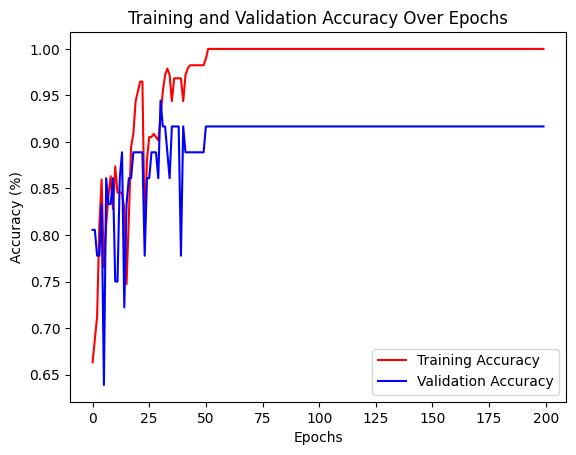

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc

# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8
epochs = 200

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# 8. Evaluate on test data from all files combined
combined_test_sequences = []
combined_test_labels = []

for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'Test Accuracy (combined files): {test_accuracy * 100:.2f}%')
print(f'Test Precision (combined files): {test_precision:.2f}')
print(f'Test Sensitivity (combined files): {test_sensitivity:.2f}')
print(f'Test F1 Score (combined files): {test_f1_score:.2f}')

# 9. Calculate percentage of exons and introns in validation set
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)
total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')

# 10. Plot overfitting graph
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# testtotalaccuracy
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc

# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 16
epochs = 40

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# 8. Evaluate on test data from all files combined

# Combine test data from all files
combined_test_sequences = []
combined_test_labels = []

for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Append sequences and labels to the combined lists
    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

# Convert combined lists to numpy arrays
combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'Test Accuracy (combined files): {test_accuracy * 100:.2f}%')
print(f'Test Precision (combined files): {test_precision:.2f}')
print(f'Test Sensitivity (combined files): {test_sensitivity:.2f}')
print(f'Test F1 Score (combined files): {test_f1_score:.2f}')

# 10. Calculate percentage of exons and introns in validation set
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 658ms/step - accuracy: 0.5677 - loss: 0.6836 - val_accuracy: 0.8056 - val_loss: 0.5854
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 599ms/step - accuracy: 0.7133 - loss: 0.6108 - val_accuracy: 0.8056 - val_loss: 0.5126
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 607ms/step - accuracy: 0.7082 - loss: 0.5733 - val_accuracy: 0.8056 - val_loss: 0.4889
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 537ms/step - accuracy: 0.7021 - loss: 0.5430 - val_accuracy: 0.8333 - val_loss: 0.4140
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 620ms/step - accuracy: 0.8258 - loss: 0.4469 - val_accuracy: 0.8611 - val_loss: 0.3945
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 652ms/step - accuracy: 0.8574 - loss: 0.4107 - val_accuracy: 0.8611 - val_loss: 0.3700
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 619ms/step - accuracy: 0.8670 - loss: 0.3668 - val_accuracy: 0.8611 - val_loss: 0.3574
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 604ms/step - accuracy: 0.9143 - loss: 0.3136 - val_accuracy: 0.861

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout  # Added Dropout here
from tensorflow.keras.utils import Sequence
import gc

# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8
epochs = 40

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),  # Removed input_length
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Added compile step

# 6. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# 8. Evaluate on test data from all files combined

# Combine test data from all files
combined_test_sequences = []
combined_test_labels = []

for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Append sequences and labels to the combined lists
    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

# Convert combined lists to numpy arrays
combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'Test Accuracy (combined files): {test_accuracy * 100:.2f}%')
print(f'Test Precision (combined files): {test_precision:.2f}')
print(f'Test Sensitivity (combined files): {test_sensitivity:.2f}')
print(f'Test F1 Score (combined files): {test_f1_score:.2f}')

# 10. Calculate percentage of exons and introns in validation set
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 640ms/step - accuracy: 0.5542 - loss: 0.6851 - val_accuracy: 0.8056 - val_loss: 0.6076
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 576ms/step - accuracy: 0.6405 - loss: 0.6577 - val_accuracy: 0.8056 - val_loss: 0.5313
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 536ms/step - accuracy: 0.6926 - loss: 0.5965 - val_accuracy: 0.6944 - val_loss: 0.5599
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 572ms/step - accuracy: 0.8078 - loss: 0.4765 - val_accuracy: 0.8056 - val_loss: 0.4453
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 590ms/step - accuracy: 0.8257 - loss: 0.4484 - val_accuracy: 0.8889 - val_loss: 0.3845
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 594ms/step - accuracy: 0.7660 - loss: 0.4770 - val_accuracy: 0.8056 - val_loss: 0.4451
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 559ms/step - accuracy: 0.8375 - loss: 0.3580 - val_accuracy: 0.8333 - val_loss: 0.3888
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 611ms/step - accuracy: 0.8367 - loss: 0.3639 - val_accuracy: 0.805

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout  # Added Dropout here
from tensorflow.keras.utils import Sequence
import gc

# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8
epochs = 40

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),  # Removed input_length
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])

# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Added compile step

# 6. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

# 8. Evaluate on test data from all files combined

# Combine test data from all files
combined_test_sequences = []
combined_test_labels = []

for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Append sequences and labels to the combined lists
    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

# Convert combined lists to numpy arrays
combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'Test Accuracy (combined files): {test_accuracy * 100:.2f}%')
print(f'Test Precision (combined files): {test_precision:.2f}')
print(f'Test Sensitivity (combined files): {test_sensitivity:.2f}')
print(f'Test F1 Score (combined files): {test_f1_score:.2f}')

# 10. Calculate percentage of exons and introns in validation set
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


799/799 ━━━━━━━━━━━━━━━━━━━━ 449s 553ms/step - accuracy: 0.7151 - loss: 0.5503 - val_accuracy: 0.6809 - val_loss: 0.5721
Epoch 2/40
799/799 ━━━━━━━━━━━━━━━━━━━━ 439s 550ms/step - accuracy: 0.8922 - loss: 0.2776 - val_accuracy: 0.9487 - val_loss: 0.1363
Epoch 3/40
786/799 ━━━━━━━━━━━━━━━━━━━━ 7s 541ms/step - accuracy: 0.9315 - loss: 0.1795

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout  # Added Dropout here
from tensorflow.keras.utils import Sequence
import gc


# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8
epochs = 40


# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
]


# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels


# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []


# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()


# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')


# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)


# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted


model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),  # Removed input_length
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])


# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Added compile step


# 6. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))


    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))


    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels


# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)


# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)


# 7. Evaluate the model on the validation data
val_predictions = model.predict(X_val)
val_predictions = (val_predictions > 0.5).astype(int)

val_accuracy = accuracy_score(y_val, val_predictions)
val_precision = precision_score(y_val, val_predictions)
val_sensitivity = recall_score(y_val, val_predictions)
val_f1_score = f1_score(y_val, val_predictions)

print(f'Validation Metrics:')
print(f'Accuracy: {val_accuracy * 100:.2f}%')
print(f'Precision: {val_precision:.2f}')
print(f'Sensitivity: {val_sensitivity:.2f}')
print(f'F1 Score: {val_f1_score:.2f}')


# 8. Evaluate on test data from each file individually
def evaluate_on_test(file_path):
    test_data = pd.read_csv(file_path)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    return test_accuracy, test_precision, test_sensitivity, test_f1_score


# Store the metrics for each test file
file_metrics = {}

for file_path in file_paths:
    accuracy, precision, sensitivity, f1 = evaluate_on_test(file_path)
    file_metrics[file_path] = {
        'accuracy': accuracy,
        'precision': precision,
        'sensitivity': sensitivity,
        'f1_score': f1
    }
    print(f'Metrics for {file_path}:')
    print(f'Accuracy: {accuracy * 100:.2f}%')
    print(f'Precision: {precision:.2f}')
    print(f'Sensitivity: {sensitivity:.2f}')
    print(f'F1 Score: {f1:.2f}')


# 9. Combine test data from all files
combined_test_sequences = []
combined_test_labels = []

for file_path in file_paths:
    test_data = pd.read_csv(file_path)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

# Convert combined lists to numpy arrays
combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculate combined test metrics
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'\nCombined Test Metrics:')
print(f'Accuracy: {test_accuracy * 100:.2f}%')
print(f'Precision: {test_precision:.2f}')
print(f'Sensitivity: {test_sensitivity:.2f}')
print(f'F1 Score: {test_f1_score:.2f}')


Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 548ms/step - accuracy: 0.5934 - loss: 0.6819 - val_accuracy: 0.8056 - val_loss: 0.5647
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 574ms/step - accuracy: 0.6647 - loss: 0.6550 - val_accuracy: 0.8056 - val_loss: 0.5115
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 568ms/step - accuracy: 0.6686 - loss: 0.6041 - val_accuracy: 0.8056 - val_loss: 0.4629
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 531ms/step - accuracy: 0.7983 - loss: 0.4902 - val_accuracy: 0.8611 - val_loss: 0.3913
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 581ms/step - accuracy: 0.8345 - loss: 0.4284 - val_accuracy: 0.8611 - val_loss: 0.3772
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 532ms/step - accuracy: 0.8126 - loss: 0.4261 - val_accuracy: 0.8333 - val_loss: 0.3723
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 577ms/step - accuracy: 0.8409 - loss: 0.3922 - val_accuracy: 0.8333 - val_loss: 0.4072
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 579ms/step - accuracy: 0.8538 - loss: 0.3244 - val_accuracy: 0.833

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout  # Added Dropout here
from tensorflow.keras.utils import Sequence
import gc


# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 16
epochs = 10


# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
]



# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels


# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []


# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()


# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')


# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)


# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted


model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),  # Removed input_length
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout after the first LSTM layer
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout after the second LSTM layer
    Dense(32, activation='relu'),
    Dropout(0.2),  # Dropout after the Dense layer
    Dense(1, activation='sigmoid')  # For binary classification
])


# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # Added compile step


# 6. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))


    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))


    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels


# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)


# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)


# 7. Evaluate the model on the validation data
val_predictions = model.predict(X_val)
val_predictions = (val_predictions > 0.5).astype(int)

val_accuracy = accuracy_score(y_val, val_predictions)
val_precision = precision_score(y_val, val_predictions)
val_sensitivity = recall_score(y_val, val_predictions)
val_f1_score = f1_score(y_val, val_predictions)

print(f'Validation Metrics:')
print(f'Accuracy: {val_accuracy * 100:.2f}%')
print(f'Precision: {val_precision:.2f}')
print(f'Sensitivity: {val_sensitivity:.2f}')
print(f'F1 Score: {val_f1_score:.2f}')


# 8. Evaluate on test data from each file individually
def evaluate_on_test(file_path):
    test_data = pd.read_csv(file_path)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    return test_accuracy, test_precision, test_sensitivity, test_f1_score


# Store the metrics for each test file
file_metrics = {}

for file_path in file_paths:
    accuracy, precision, sensitivity, f1 = evaluate_on_test(file_path)
    file_metrics[file_path] = {
        'accuracy': accuracy,
        'precision': precision,
        'sensitivity': sensitivity,
        'f1_score': f1
    }
    print(f'Metrics for {file_path}:')
    print(f'Accuracy: {accuracy * 100:.2f}%')
    print(f'Precision: {precision:.2f}')
    print(f'Sensitivity: {sensitivity:.2f}')
    print(f'F1 Score: {f1:.2f}')


# 9. Combine test data from all files
combined_test_sequences = []
combined_test_labels = []

for file_path in file_paths:
    test_data = pd.read_csv(file_path)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

# Convert combined lists to numpy arrays
combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

# Evaluate the model on the combined test data
test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

# Calculate combined test metrics
test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'\nCombined Test Metrics:')
print(f'Accuracy: {test_accuracy * 100:.2f}%')
print(f'Precision: {test_precision:.2f}')
print(f'Sensitivity: {test_sensitivity:.2f}')
print(f'F1 Score: {test_f1_score:.2f}')


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


400/400 ━━━━━━━━━━━━━━━━━━━━ 243s 589ms/step - accuracy: 0.7801 - loss: 0.4453 - val_accuracy: 0.9449 - val_loss: 0.1553
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 234s 586ms/step - accuracy: 0.9359 - loss: 0.1826 - val_accuracy: 0.9299 - val_loss: 0.1750
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 236s 589ms/step - accuracy: 0.9395 - loss: 0.1663 - val_accuracy: 0.9675 - val_loss: 0.1128
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 236s 590ms/step - accuracy: 0.9387 - loss: 0.1739 - val_accuracy: 0.9574 - val_loss: 0.0916
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 260s 586ms/step - accuracy: 0.9616 - loss: 0.1152 - val_accuracy: 0.9775 - val_loss: 0.0801
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 235s 587ms/step - accuracy: 0.9709 - loss: 0.0849 - val_accuracy: 0.9537 - val_loss: 0.1413
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 260s 582ms/step - accuracy: 0.9710 - loss: 0.0753 - val_accuracy: 0.9837 - val_loss: 0.0541
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 234s 585ms/step - accuracy: 0.9824 - loss: 0.05

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc

# Parameters
chunk_size = 10000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32
epochs = 20

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(16)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 7. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 8. Plot training vs validation loss and accuracy
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 9. Evaluate on test data
def evaluate_on_test(file_path):
    test_data = pd.read_csv(file_path)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    return test_accuracy, test_precision, test_sensitivity, test_f1_score

# 10. Evaluate model on combined test data
combined_test_sequences = []
combined_test_labels = []

for file_path in file_paths:
    test_data = pd.read_csv(file_path)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    combined_test_sequences.extend(padded_test_sequences)
    combined_test_labels.extend(test_labels)

combined_test_sequences = np.array(combined_test_sequences)
combined_test_labels = np.array(combined_test_labels, dtype=np.int8)

test_predictions = model.predict(combined_test_sequences)
test_predictions = (test_predictions > 0.5).astype(int)

test_accuracy = accuracy_score(combined_test_labels, test_predictions)
test_precision = precision_score(combined_test_labels, test_predictions)
test_sensitivity = recall_score(combined_test_labels, test_predictions)
test_f1_score = f1_score(combined_test_labels, test_predictions)

print(f'\nCombined Test Metrics:')
print(f'Accuracy: {test_accuracy * 100:.2f}%')
print(f'Precision: {test_precision:.2f}')
print(f'Sensitivity: {test_sensitivity:.2f}')
print(f'F1 Score: {test_f1_score:.2f}')


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 159s 739ms/step - accuracy: 0.7446 - loss: 0.5572 - val_accuracy: 0.8773 - val_loss: 0.2936
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 208s 770ms/step - accuracy: 0.9099 - loss: 0.2488 - val_accuracy: 0.9487 - val_loss: 0.1672
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 194s 731ms/step - accuracy: 0.9527 - loss: 0.1459 - val_accuracy: 0.9474 - val_loss: 0.1505
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 202s 729ms/step - accuracy: 0.9430 - loss: 0.1725 - val_accuracy: 0.9462 - val_loss: 0.1397
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 147s 736ms/step - accuracy: 0.9605 - loss: 0.1085 - val_accuracy: 0.9850 - val_loss: 0.0611
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 201s 729ms/step - accuracy: 0.9807 - loss: 0.0603 - val_accuracy: 0.9850 - val_loss: 0.0543
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 143s 714ms/step - accuracy: 0.9731 - loss: 0.1004 - val_accuracy: 0.9750 - val_loss: 0.0810
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 202s 717ms/step - accuracy: 0.9655 - loss: 0.09

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 16  # Adjust batch size if needed
epochs = 20  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Use all files for training
train_files = file_paths

# Process CSV files in chunks for training
for file_path in train_files:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')

# 8. Load the test data from all files and evaluate
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 10. Calculate percentage of exons and introns in validation and test sets
exons_val = np.sum(y_val == 1)
introns_val = np.sum(y_val == 0)

total_val = len(y_val)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set: {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 695ms/step - accuracy: 0.5979 - loss: 0.6845 - val_accuracy: 0.8056 - val_loss: 0.6225
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 706ms/step - accuracy: 0.6959 - loss: 0.6329 - val_accuracy: 0.8056 - val_loss: 0.5261
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 705ms/step - accuracy: 0.6868 - loss: 0.5725 - val_accuracy: 0.7778 - val_loss: 0.4605
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 619ms/step - accuracy: 0.7806 - loss: 0.4963 - val_accuracy: 0.7500 - val_loss: 0.4636
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 720ms/step - accuracy: 0.7811 - loss: 0.4756 - val_accuracy: 0.8611 - val_loss: 0.3959
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 714ms/step - accuracy: 0.8219 - loss: 0.4544 - val_accuracy: 0.7778 - val_loss: 0.4591
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 703ms/step - accuracy: 0.8136 - loss: 0.4022 - val_accuracy: 0.8333 - val_loss: 0.4621
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 697ms/step - accuracy: 0.8277 - loss: 0.4417 - val_accuracy: 0.861

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random

# Parameters
chunk_size = 1000
max_len_limit = 1000  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 20  # Adjust the number of epochs if needed

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv"
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files and take 10% sample for validation
sampled_sequences_list = []
sampled_labels_list = []

# Process CSV files in chunks for training and sampling
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)

        # Take a 10% sample from the chunk for validation
        sample_size = int(len(sequences) * 0.1)
        sample_indices = np.random.choice(len(sequences), size=sample_size, replace=False)

        sampled_sequences_list.extend([sequences[i] for i in sample_indices])
        sampled_labels_list.extend([labels[i] for i in sample_indices])

        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# Tokenize and pad sampled validation sequences
encoded_sampled_sequences = tokenizer.texts_to_sequences(sampled_sequences_list)
padded_sampled_sequences = pad_sequences(encoded_sampled_sequences, maxlen=max_len, padding='post')

# Convert sampled labels to numpy array
sampled_labels = np.array(sampled_labels_list, dtype=np.int8)

# 3. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(padded_sampled_sequences, sampled_labels, batch_size)

# 6. Train the model
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluate the model on the validation sample data during training
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Final Validation Accuracy on Sampled Data: {val_accuracy*100:.2f}%')

# 8. Evaluate the model on the test data
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate the model on the test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)

    # Calculate test metrics
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    print(f'Results for {test_file}:')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')  # Separador entre os resultados

# 9. Calculate percentage of exons and introns in the sampled validation set
exons_val = np.sum(sampled_labels == 1)
introns_val = np.sum(sampled_labels == 0)

total_val = len(sampled_labels)

exons_val_pct = (exons_val / total_val) * 100
introns_val_pct = (introns_val / total_val) * 100

print(f'Validation Set (Sampled Data): {exons_val_pct:.2f}% Exons, {introns_val_pct:.2f}% Introns')


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.5351 - loss: 0.6886 - val_accuracy: 0.6176 - val_loss: 0.6676
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6442 - loss: 0.6690 - val_accuracy: 0.7059 - val_loss: 0.6310
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6537 - loss: 0.6471 - val_accuracy: 0.7059 - val_loss: 0.5928
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6514 - loss: 0.6184 - val_accuracy: 0.7059 - val_loss: 0.5361
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6480 - loss: 0.5719 - val_accuracy: 0.7941 - val_loss: 0.4537
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7996 - loss: 0.4717 - val_accuracy: 0.8529 - val_loss: 0.4043
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8314 - loss: 0.4512 - val_accuracy: 0.8529 - val_loss: 0.3976
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7506 - loss: 0.4938 - val_accuracy: 0.8529 - val_loss: 0.3910
Epoch 9/20
9/9 ━━━━

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 798ms/step - accuracy: 0.6900 - loss: 0.5875 - val_accuracy: 0.9399 - val_loss: 0.2271
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 764ms/step - accuracy: 0.9085 - loss: 0.2604 - val_accuracy: 0.9449 - val_loss: 0.1634
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 805ms/step - accuracy: 0.9507 - loss: 0.1529 - val_accuracy: 0.9762 - val_loss: 0.0952
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 770ms/step - accuracy: 0.9668 - loss: 0.1147 - val_accuracy: 0.9612 - val_loss: 0.1209
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 765ms/step - accuracy: 0.9680 - loss: 0.0945 - val_accuracy: 0.9725 - val_loss: 0.0795
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 776ms/step - accuracy: 0.9645 - loss: 0.1020 - val_accuracy: 0.9812 - val_loss: 0.0599
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 80s 759ms/step - accuracy: 0.9843 - loss: 0.0524 - val_accuracy: 0.9862 - val_loss: 0.0525
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 757ms/step - accuracy: 0.9841 - loss: 0.050

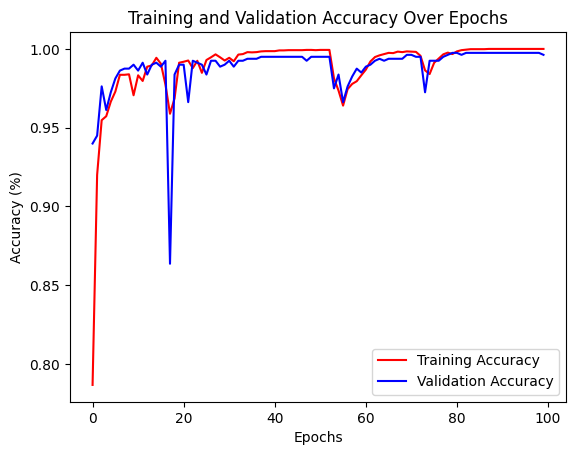

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step
Results for /content/PPIAFIX2_test_CORRECTED.csv:
Validation Accuracy: 99.62%
Test Accuracy: 98.59%
Test Precision: 1.00
Test Sensitivity: 0.97
Test F1 Score: 0.99
---
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
Results for /content/GADPH_test_CORRECTED.csv:
Validation Accuracy: 99.62%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 99.62%
Test Accuracy: 97.06%
Test Precision: 0.97
Test Sensitivity: 0.97
Test F1 Score: 0.97
---
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step
Results for /content/TTN_test_CORRECTED.csv:
Validation Accuracy: 99.62%
Test Accuracy: 99.99%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
             

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.5018 - loss: 0.6916 - val_accuracy: 0.8333 - val_loss: 0.6773
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7115 - loss: 0.6798 - val_accuracy: 0.8056 - val_loss: 0.6532
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6710 - loss: 0.6654 - val_accuracy: 0.8056 - val_loss: 0.6182
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 829ms/step - accuracy: 0.6796 - loss: 0.6396 - val_accuracy: 0.8056 - val_loss: 0.5751
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6775 - loss: 0.6203 - val_accuracy: 0.8056 - val_loss: 0.5421
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 623ms/step - accuracy: 0.6852 - loss: 0.6070 - val_accuracy: 0.8056 - val_loss: 0.5190
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 622ms/step - accuracy: 0.6773 - loss: 0.6032 - val_accuracy: 0.8056 - val_loss: 0.5106
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 855ms/step - accuracy: 0.6869 - loss: 0.5912 - val_accuracy: 0.8056 - val_loss: 0.4926
Epoch 9

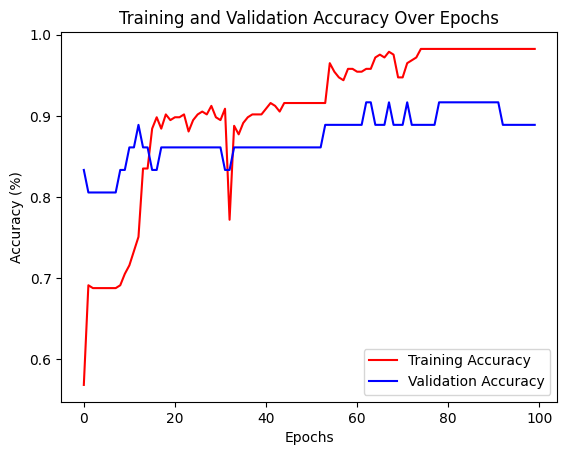

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step
Results for /content/PPIAFIX2_test_CORRECTED.csv:
Validation Accuracy: 88.89%
Test Accuracy: 95.07%
Test Precision: 0.99
Test Sensitivity: 0.93
Test F1 Score: 0.95
---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
Results for /content/GADPH_test_CORRECTED.csv:
Validation Accuracy: 88.89%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 88.89%
Test Accuracy: 97.06%
Test Precision: 0.97
Test Sensitivity: 0.97
Test F1 Score: 0.97
---
                                   File  Validation ACC  Validation PRE  \
0  /content/PPIAFIX2_test_CORRECTED.csv       88.888889        0.913043   
1     /content/GADPH_test_CORRECTED.csv       88.888889        0.913043   
2    /content/B2MFIX_test_CORRECTED.csv      

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random
from tensorflow.keras.layers import Dropout

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8  # Adjust batch size if needed
epochs = 200  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)


# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout layer added here
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout layer added here
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 8. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 9. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 10. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 11. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)

# ADDITIONAL CODE BLOCK - Calculating Sensitivity and Specificity
def calculate_sensitivity_specificity(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    tp = np.sum((y_true == 1) & (predictions == 1))  # True Positives
    tn = np.sum((y_true == 0) & (predictions == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (predictions == 1))  # False Positives
    fn = np.sum((y_true == 1) & (predictions == 0))  # False Negatives

    sensitivity = tp / (tp + fn)  # Sensitivity calculation
    specificity = tn / (tn + fp)  # Specificity calculation

    return sensitivity, specificity

# Example usage:
sensitivity, specificity = calculate_sensitivity_specificity(validation_generator, y_val)
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/200


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5102 - loss: 0.6865 - val_accuracy: 0.8056 - val_loss: 0.5810
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 970ms/step - accuracy: 0.7087 - loss: 0.6041 - val_accuracy: 0.7778 - val_loss: 0.4929
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 719ms/step - accuracy: 0.7940 - loss: 0.4945 - val_accuracy: 0.7778 - val_loss: 0.4722
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 542ms/step - accuracy: 0.8039 - loss: 0.4807 - val_accuracy: 0.8333 - val_loss: 0.4358
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 604ms/step - accuracy: 0.8534 - loss: 0.3873 - val_accuracy: 0.8611 - val_loss: 0.4188
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 617ms/step - accuracy: 0.9176 - loss: 0.2836 - val_accuracy: 0.8611 - val_loss: 0.4062
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 592ms/step - accuracy: 0.8618 - loss: 0.3740 - val_accuracy: 0.8333 - val_loss: 0.4406
Epoch 8/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 542ms/step - accuracy: 0.8770 - loss: 0.3438 - val_accuracy: 0

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 388ms/step
Results for /content/PPIAFIX2_test_CORRECTED.csv:
Validation Accuracy: 91.67%
Test Accuracy: 98.59%
Test Precision: 0.99
Test Sensitivity: 0.99
Test F1 Score: 0.99
---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step
Results for /content/GADPH_test_CORRECTED.csv:
Validation Accuracy: 91.67%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 91.67%
Test Accuracy: 98.53%
Test Precision: 0.98
Test Sensitivity: 1.00
Test F1 Score: 0.99
---
                                   File  Validation ACC  Validation PRE  \
0  /content/PPIAFIX2_test_CORRECTED.csv       91.666667        0.916667   
1     /content/GADPH_test_CORRECTED.csv       91.666667        0.916667   
2    /content/B2MFIX_test_CORRECTED.csv       91.666667        0.916667   

   Vali

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random
from tensorflow.keras.layers import Dropout

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8  # Adjust batch size if needed
epochs = 20  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)


# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout layer added here
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout layer added here
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 8. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 9. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 10. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 11. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)

# ADDITIONAL CODE BLOCK - Calculating Sensitivity and Specificity
def calculate_sensitivity_specificity(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    tp = np.sum((y_true == 1) & (predictions == 1))  # True Positives
    tn = np.sum((y_true == 0) & (predictions == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (predictions == 1))  # False Positives
    fn = np.sum((y_true == 1) & (predictions == 0))  # False Negatives

    sensitivity = tp / (tp + fn)  # Sensitivity calculation
    specificity = tn / (tn + fp)  # Specificity calculation

    return sensitivity, specificity

# Example usage:
sensitivity, specificity = calculate_sensitivity_specificity(validation_generator, y_val)
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 583ms/step - accuracy: 0.5611 - loss: 0.6842 - val_accuracy: 0.8056 - val_loss: 0.5692
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 540ms/step - accuracy: 0.7018 - loss: 0.6133 - val_accuracy: 0.8056 - val_loss: 0.5278
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 591ms/step - accuracy: 0.6730 - loss: 0.6010 - val_accuracy: 0.8333 - val_loss: 0.4342
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 542ms/step - accuracy: 0.7493 - loss: 0.5053 - val_accuracy: 0.8056 - val_loss: 0.4822
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 590ms/step - accuracy: 0.8334 - loss: 0.4449 - val_accuracy: 0.8056 - val_loss: 0.4103
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 589ms/step - accuracy: 0.8568 - loss: 0.3900 - val_accuracy: 0.7778 - val_loss: 0.4403
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 587ms/step - accuracy: 0.9039 - loss: 0.3061 - val_accuracy: 0.8333 - val_loss: 0.4291
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 575ms/step - accuracy: 0.8195 - loss: 0.4225 - val_accuracy: 0.833

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step
Results for /content/PPIAFIX2_test_CORRECTED.csv:
Validation Accuracy: 80.56%
Test Accuracy: 82.39%
Test Precision: 1.00
Test Sensitivity: 0.69
Test F1 Score: 0.81
---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
Results for /content/GADPH_test_CORRECTED.csv:
Validation Accuracy: 80.56%
Test Accuracy: 96.60%
Test Precision: 1.00
Test Sensitivity: 0.94
Test F1 Score: 0.97
---
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 80.56%
Test Accuracy: 91.18%
Test Precision: 0.95
Test Sensitivity: 0.90
Test F1 Score: 0.92
---
                                   File  Validation ACC  Validation PRE  \
0  /content/PPIAFIX2_test_CORRECTED.csv       80.555556        0.944444   
1     /content/GADPH_test_CORRECTED.csv       80.555556        0.944444   
2    /content/B2MFIX_test_CORRECTED.csv       80.555556        0.944444   

   Vali

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import random
from tensorflow.keras.layers import Dropout

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8  # Adjust batch size if needed
epochs = 20  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)


# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Dropout(0.2),  # Dropout layer added here
    Bidirectional(LSTM(16)),
    Dropout(0.2),  # Dropout layer added here
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 8. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 9. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 10. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 11. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)

# ADDITIONAL CODE BLOCK - Calculating Sensitivity and Specificity
def calculate_sensitivity_specificity(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    tp = np.sum((y_true == 1) & (predictions == 1))  # True Positives
    tn = np.sum((y_true == 0) & (predictions == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (predictions == 1))  # False Positives
    fn = np.sum((y_true == 1) & (predictions == 0))  # False Negatives

    sensitivity = tp / (tp + fn)  # Sensitivity calculation
    specificity = tn / (tn + fp)  # Specificity calculation

    return sensitivity, specificity

# Example usage:
sensitivity, specificity = calculate_sensitivity_specificity(validation_generator, y_val)
print(f"Sensitivity: {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


799/799 ━━━━━━━━━━━━━━━━━━━━ 454s 559ms/step - accuracy: 0.8001 - loss: 0.4250 - val_accuracy: 0.8849 - val_loss: 0.2677
Epoch 2/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 446s 558ms/step - accuracy: 0.8997 - loss: 0.2584 - val_accuracy: 0.9362 - val_loss: 0.1748
Epoch 3/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 447s 560ms/step - accuracy: 0.9374 - loss: 0.1607 - val_accuracy: 0.9524 - val_loss: 0.1090
Epoch 4/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 451s 564ms/step - accuracy: 0.9628 - loss: 0.0909 - val_accuracy: 0.9650 - val_loss: 0.1073
Epoch 5/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 448s 561ms/step - accuracy: 0.9546 - loss: 0.1093 - val_accuracy: 0.9762 - val_loss: 0.0696
Epoch 6/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 504s 564ms/step - accuracy: 0.9735 - loss: 0.0684 - val_accuracy: 0.9800 - val_loss: 0.0566
Epoch 7/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 449s 562ms/step - accuracy: 0.9837 - loss: 0.0545 - val_accuracy: 0.9750 - val_loss: 0.0702
Epoch 8/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 451s 565ms/step - accuracy: 0.9667 - loss: 0.08

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


117/117 ━━━━━━━━━━━━━━━━━━━━ 88s 696ms/step - accuracy: 0.7502 - loss: 0.5238 - val_accuracy: 0.8894 - val_loss: 0.3774
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 83s 714ms/step - accuracy: 0.9333 - loss: 0.2205 - val_accuracy: 0.9517 - val_loss: 0.1437
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 81s 696ms/step - accuracy: 0.9709 - loss: 0.1048 - val_accuracy: 0.9817 - val_loss: 0.0846
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 81s 693ms/step - accuracy: 0.9735 - loss: 0.0961 - val_accuracy: 0.9549 - val_loss: 0.1623
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 81s 694ms/step - accuracy: 0.9401 - loss: 0.1762 - val_accuracy: 0.9764 - val_loss: 0.0751
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 81s 684ms/step - accuracy: 0.9474 - loss: 0.1476 - val_accuracy: 0.9785 - val_loss: 0.0957
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 82s 684ms/step - accuracy: 0.9763 - loss: 0.0924 - val_accuracy: 0.9860 - val_loss: 0.0559
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 83s 696ms/step - accuracy: 0.9820 - loss: 0.066

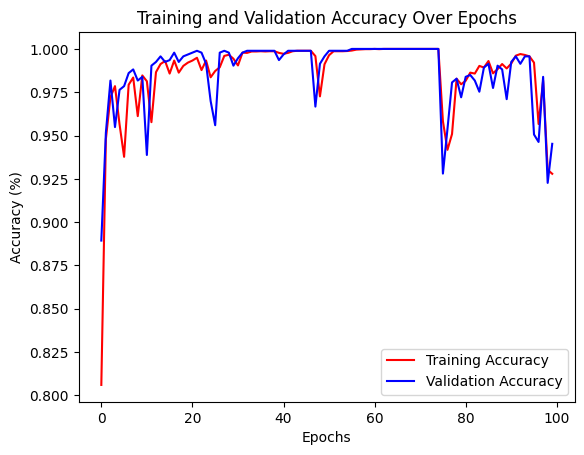

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step
Results for /content/NEB_test_test_CORRECTED.csv:
Validation Accuracy: 94.52%
Test Accuracy: 86.14%
Test Precision: 0.97
Test Sensitivity: 0.75
Test F1 Score: 0.85
---
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Results for /content/ANKRD1_test_CORRECTED.csv:
Validation Accuracy: 94.52%
Test Accuracy: 88.24%
Test Precision: 0.89
Test Sensitivity: 0.89
Test F1 Score: 0.89
---
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step
Results for /content/TTN_test_CORRECTED.csv:
Validation Accuracy: 94.52%
Test Accuracy: 95.83%
Test Precision: 1.00
Test Sensitivity: 0.92
Test F1 Score: 0.96
---
                                   File  Validation ACC  Validation PRE  \
0  /content/NEB_test_test_CORRECTED.csv       94.522019        0.995294   
1    /content/ANKRD1_test_CORRECTED.csv       94.522019        0.995294   
2       /content/TTN_test_CORREC

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/NEB_test_test_CORRECTED.csv",
  "/content/ANKRD1_test_CORRECTED.csv",
  "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 738ms/step - accuracy: 0.8548 - loss: 0.6205 - val_accuracy: 0.8263 - val_loss: 0.4731
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 709ms/step - accuracy: 0.8680 - loss: 0.4000 - val_accuracy: 0.8323 - val_loss: 0.3951
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 702ms/step - accuracy: 0.8327 - loss: 0.3958 - val_accuracy: 0.8323 - val_loss: 0.3594
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 729ms/step - accuracy: 0.8419 - loss: 0.3540 - val_accuracy: 0.8323 - val_loss: 0.2889
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 696ms/step - accuracy: 0.8575 - loss: 0.2787 - val_accuracy: 0.8743 - val_loss: 0.2339
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 704ms/step - accuracy: 0.9274 - loss: 0.2157 - val_accuracy: 0.9341 - val_loss: 0.1851
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 704ms/step - accuracy: 0.9457 - loss: 0.1849 - val_accuracy: 0.9281 - val_loss: 0.1917
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 704ms/step - accuracy: 0.9505 - loss: 0.1695 - val_accuracy

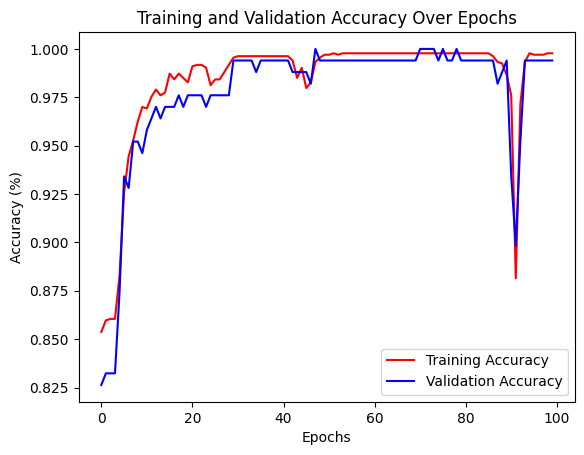

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step
Results for /content/NEB_test_test_CORRECTED.csv:
Validation Accuracy: 99.40%
Test Accuracy: 99.52%
Test Precision: 0.99
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                   File  Validation ACC  Validation PRE  \
0  /content/NEB_test_test_CORRECTED.csv       99.401198        0.988636   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0        0.994286  99.520096   0.99409  0.996445  0.995266  
Results with Total Metrics:
                                   File  Validation ACC  Validation PRE  \
0  /content/NEB_test_test_CORRECTED.csv       99.401198        0.988636   
1                                 Total       99.401198        0.988636   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0        0.994286  99.520096   0.99409  0.996445  0.995266  
1             1.0        0.994286  99.5

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/NEB_test_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.7082 - loss: 0.6676 - val_accuracy: 0.8631 - val_loss: 0.4953
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 765ms/step - accuracy: 0.8398 - loss: 0.4512 - val_accuracy: 0.8690 - val_loss: 0.3061
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 736ms/step - accuracy: 0.8648 - loss: 0.2915 - val_accuracy: 0.8571 - val_loss: 0.2856
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 734ms/step - accuracy: 0.9081 - loss: 0.2459 - val_accuracy: 0.9405 - val_loss: 0.2109
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 737ms/step - accuracy: 0.9436 - loss: 0.1881 - val_accuracy: 0.9345 - val_loss: 0.2067
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 811ms/step - accuracy: 0.9438 - loss: 0.1917 - val_accuracy: 0.9583 - val_loss: 0.1747
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 744ms/step - accuracy: 0.9470 - loss: 0.1665 - val_accuracy: 0.9464 - val_loss: 0.1555
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 846ms/step - accuracy: 0.9500 - loss: 0.1700 - val_accuracy: 0

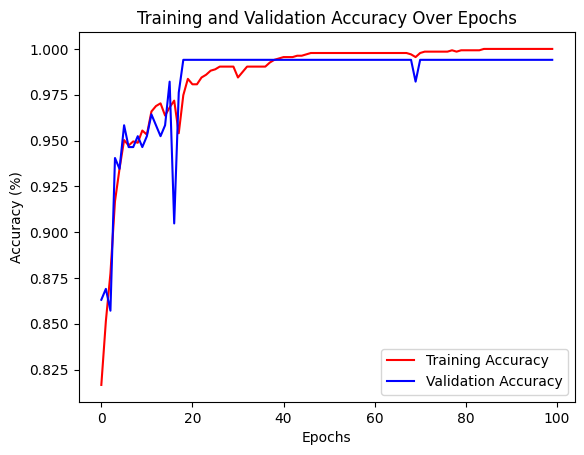

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step
Results for /content/NEB_test_test_CORRECTED.csv:
Validation Accuracy: 99.40%
Test Accuracy: 99.94%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Results for /content/ANKRD1_test_CORRECTED.csv:
Validation Accuracy: 99.40%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                   File  Validation ACC  Validation PRE  \
0  /content/NEB_test_test_CORRECTED.csv       99.404762             1.0   
1    /content/ANKRD1_test_CORRECTED.csv       99.404762             1.0   

   Validation SEN  Validation F1S    Test ACC  Test PRE  Test SEN  Test F1S  
0        0.988506         0.99422   99.940012       1.0  0.998815  0.999407  
1        0.988506         0.99422  100.000000       1.0  1.000000  1.000000  
Results with Total Metrics:
                   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/NEB_test_test_CORRECTED.csv",
  "/content/ANKRD1_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5425 - loss: 0.6917 - val_accuracy: 0.5455 - val_loss: 0.6903
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 697ms/step - accuracy: 0.5461 - loss: 0.6888 - val_accuracy: 0.5455 - val_loss: 0.6880
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 700ms/step - accuracy: 0.5695 - loss: 0.6844 - val_accuracy: 0.5455 - val_loss: 0.6856
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 686ms/step - accuracy: 0.5695 - loss: 0.6802 - val_accuracy: 0.5455 - val_loss: 0.6827
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 714ms/step - accuracy: 0.5359 - loss: 0.6796 - val_accuracy: 0.5455 - val_loss: 0.6781
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5724 - loss: 0.6703 - val_accuracy: 0.5455 - val_loss: 0.6729
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 707ms/step - accuracy: 0.5695 - loss: 0.6642 - val_accuracy: 0.5455 - val_loss: 0.6645
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 707ms/step - accuracy: 0.6069 - loss: 0.6557 - val_accuracy: 0.7727 - val_loss: 0.6528
E

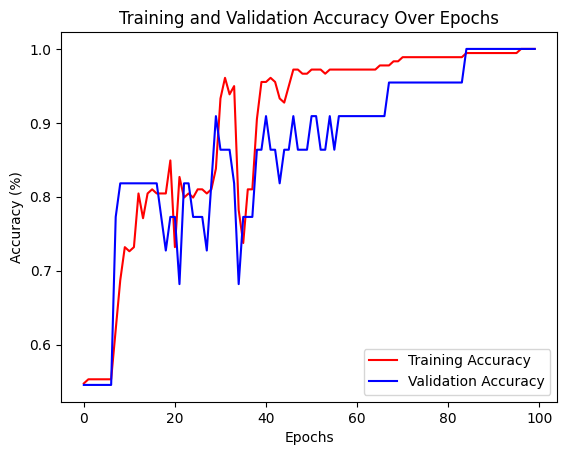

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
Results for /content/RPLA13ALLAMAPPIA2_test_CORRECTED.csv:
Validation Accuracy: 100.00%
Test Accuracy: 99.55%
Test Precision: 0.99
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                            File  Validation ACC  \
0  /content/RPLA13ALLAMAPPIA2_test_CORRECTED.csv           100.0   

   Validation PRE  Validation SEN  Validation F1S   Test ACC  Test PRE  \
0             1.0             1.0             1.0  99.553571  0.991935   

   Test SEN  Test F1S  
0       1.0  0.995951  
Results with Total Metrics:
                                            File  Validation ACC  \
0  /content/RPLA13ALLAMAPPIA2_test_CORRECTED.csv           100.0   
1                                          Total           100.0   

   Validation PRE  Validation SEN  Validation F1S   Test ACC  Test PRE  \
0             1.0             1.0             1.0  99.553571  0.991935   
1             1.0            

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/RPLA13ALLAMAPPIA2_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 656ms/step - accuracy: 0.6171 - loss: 0.6866 - val_accuracy: 0.8571 - val_loss: 0.6553
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 832ms/step - accuracy: 0.8178 - loss: 0.6532 - val_accuracy: 0.8571 - val_loss: 0.5922
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 0.8171 - loss: 0.5912 - val_accuracy: 0.8571 - val_loss: 0.5216
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 0.8343 - loss: 0.5214 - val_accuracy: 0.8571 - val_loss: 0.4483
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 741ms/step - accuracy: 0.8206 - loss: 0.4772 - val_accuracy: 0.8571 - val_loss: 0.4058
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 548ms/step - accuracy: 0.7908 - loss: 0.4947 - val_accuracy: 0.8571 - val_loss: 0.3977
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 543ms/step - accuracy: 0.7702 - loss: 0.5060 - val_accuracy: 0.8571 - val_loss: 0.3998
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 820ms/step - accuracy: 0.7120 - loss: 0.5622 - val_accuracy: 0.8571 - val_loss: 0.

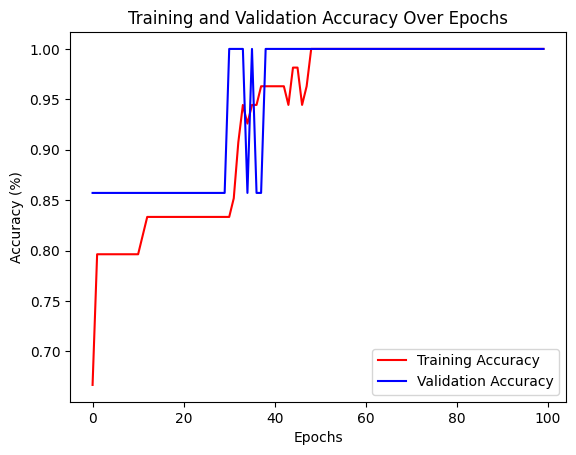

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step
Results for /content/PGK1LLAMAPIA2_test_CORRECTED.csv:
Validation Accuracy: 100.00%
Test Accuracy: 98.53%
Test Precision: 1.00
Test Sensitivity: 0.97
Test F1 Score: 0.99
---
                                        File  Validation ACC  Validation PRE  \
0  /content/PGK1LLAMAPIA2_test_CORRECTED.csv           100.0             1.0   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0  98.529412       1.0  0.972973  0.986301  
Results with Total Metrics:
                                        File  Validation ACC  Validation PRE  \
0  /content/PGK1LLAMAPIA2_test_CORRECTED.csv           100.0             1.0   
1                                      Total           100.0             1.0   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0  98.529412       1.0  0.972973  0.986301  
1             1.0             1.0  98.529412     

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 8  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/PGK1LLAMAPIA2_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.7593 - loss: 0.6921 - val_accuracy: 0.5714 - val_loss: 0.6886
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5185 - loss: 0.6886 - val_accuracy: 0.5714 - val_loss: 0.6831
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step - accuracy: 0.5185 - loss: 0.6840 - val_accuracy: 0.7143 - val_loss: 0.6764
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step - accuracy: 0.7407 - loss: 0.6789 - val_accuracy: 0.7143 - val_loss: 0.6689
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step - accuracy: 0.7963 - loss: 0.6732 - val_accuracy: 0.7143 - val_loss: 0.6615
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step - accuracy: 0.7963 - loss: 0.6671 - val_accuracy: 0.7143 - val_loss: 0.6533
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step - accuracy: 0.7963 - loss: 0.6608 - val_accuracy: 0.7143 - val_loss: 0.6448
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step - accuracy: 0.7963 - loss: 0.6542 - val_accuracy: 0.7143 - val_loss: 0.6361
Ep

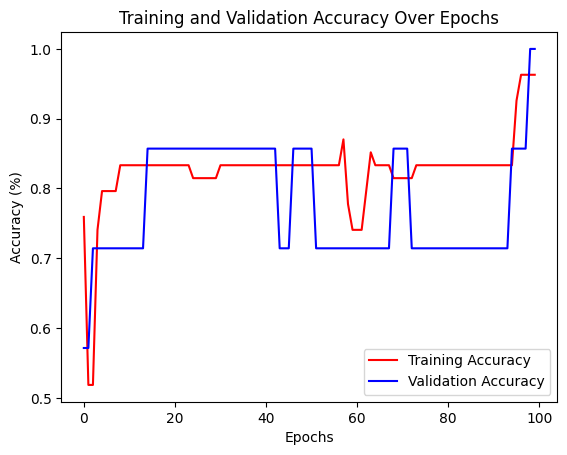

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step
Results for /content/PGK1LLAMAPIA2_test_CORRECTED.csv:
Validation Accuracy: 100.00%
Test Accuracy: 95.59%
Test Precision: 1.00
Test Sensitivity: 0.92
Test F1 Score: 0.96
---
                                        File  Validation ACC  Validation PRE  \
0  /content/PGK1LLAMAPIA2_test_CORRECTED.csv           100.0             1.0   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0  95.588235       1.0  0.918919  0.957746  
Results with Total Metrics:
                                        File  Validation ACC  Validation PRE  \
0  /content/PGK1LLAMAPIA2_test_CORRECTED.csv           100.0             1.0   
1                                      Total           100.0             1.0   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0  95.588235       1.0  0.918919  0.957746  
1         

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 64  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/PGK1LLAMAPIA2_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Build the Bidirectional LSTM model
vocab_size = len(tokenizer.word_index) + 1  # Add space for padding index
embedding_dim = 32  # Can be adjusted

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(16, return_sequences=True)),
    Bidirectional(LSTM(16)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification; adjust for multiclass
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.4630 - loss: 0.6918 - val_accuracy: 0.8571 - val_loss: 0.6838
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7789 - loss: 0.6833 - val_accuracy: 0.8571 - val_loss: 0.6697
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7884 - loss: 0.6697 - val_accuracy: 0.8571 - val_loss: 0.6483
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.7884 - loss: 0.6490 - val_accuracy: 0.8571 - val_loss: 0.6150
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7884 - loss: 0.6147 - val_accuracy: 0.8571 - val_loss: 0.5695
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7884 - loss: 0.5799 - val_accuracy: 0.8571 - val_loss: 0.5150
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 3s/step - accuracy: 0.7884 - loss: 0.5448 - val_accuracy: 0.8571 - val_loss: 0.4596
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7884 - loss: 0.5088 - val_accuracy: 0.8571 - val_loss: 0.4157
Epoch 9/100
2/2 ━━━

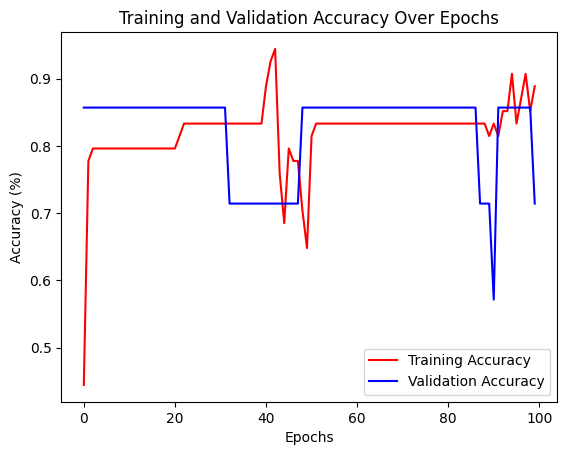

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 579ms/step
Results for /content/PGK1LLAMAPIA2_test_CORRECTED.csv:
Validation Accuracy: 71.43%
Test Accuracy: 89.71%
Test Precision: 0.97
Test Sensitivity: 0.84
Test F1 Score: 0.90
---
                                        File  Validation ACC  Validation PRE  \
0  /content/PGK1LLAMAPIA2_test_CORRECTED.csv       71.428571            0.75   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0            0.75            0.75  89.705882   0.96875  0.837838  0.898551  
Results with Total Metrics:
                                        File  Validation ACC  Validation PRE  \
0  /content/PGK1LLAMAPIA2_test_CORRECTED.csv       71.428571            0.75   
1                                      Total       71.428571            0.75   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0            0.75            0.75  89.705882   0.96875  0.837838  0.898551  
1          

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
file_paths = [
  "/content/PGK1LLAMAPIA2_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.8045 - loss: 0.4275 - val_accuracy: 0.9378 - val_loss: 0.1537
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 187s 748ms/step - accuracy: 0.9457 - loss: 0.1471 - val_accuracy: 0.9508 - val_loss: 0.1100
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 183s 733ms/step - accuracy: 0.9355 - loss: 0.1494 - val_accuracy: 0.9699 - val_loss: 0.0900
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 203s 738ms/step - accuracy: 0.9701 - loss: 0.0788 - val_accuracy: 0.9789 - val_loss: 0.0689
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 206s 753ms/step - accuracy: 0.9696 - loss: 0.0871 - val_accuracy: 0.9669 - val_loss: 0.0796
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 184s 734ms/step - accuracy: 0.9726 - loss: 0.0650 - val_accuracy: 0.9839 - val_loss: 0.0551
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 184s 737ms/step - accuracy: 0.9794 - loss: 0.0551 - val_accuracy: 0.9890 - val_loss: 0.0323
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 185s 738ms/step - accuracy: 0.9882 - loss: 

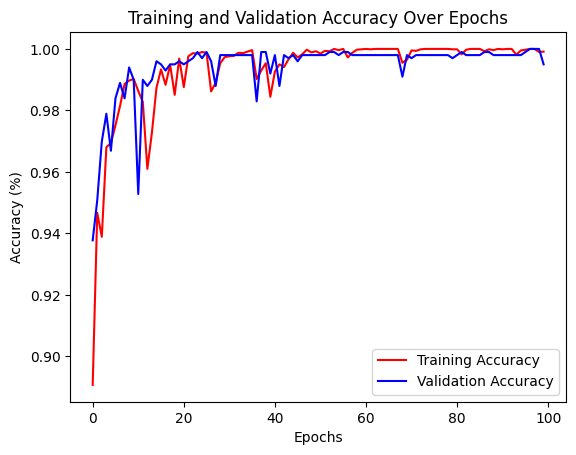

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step
Results for /content/ANKRD1_test_CORRECTED.csv:
Validation Accuracy: 99.50%
Test Accuracy: 94.12%
Test Precision: 0.90
Test Sensitivity: 1.00
Test F1 Score: 0.95
---
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 99.50%
Test Accuracy: 98.53%
Test Precision: 0.98
Test Sensitivity: 1.00
Test F1 Score: 0.99
---
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
Results for /content/PPIAFIX2_test_CORRECTED.csv:
Validation Accuracy: 99.50%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step
Results for /content/GADPH_test_CORRECTED.csv:
Validation Accuracy: 99.50%
Test Accuracy: 99.32%
Test Precision: 0.99
Test Sensitivity: 1.00
Test F1 Score: 0.99
---
32/32 ━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [
  "/content/ANKRD1_test_CORRECTED.csv",
  "/content/B2MFIX_test_CORRECTED.csv",
  "/content/PPIAFIX2_test_CORRECTED.csv",
  "/content/GADPH_test_CORRECTED.csv",
  "/content/PGK1_test_CORRECTED.csv",
  "/content/RPLA13A_test_CORRECTED.csv",
  "/content/NEB_test_test_CORRECTED.csv",
  "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


238/238 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.7507 - loss: 0.5162 - val_accuracy: 0.9317 - val_loss: 0.1700
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.9180 - loss: 0.2012 - val_accuracy: 0.8634 - val_loss: 0.3310
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 231s 970ms/step - accuracy: 0.8861 - loss: 0.2893 - val_accuracy: 0.8929 - val_loss: 0.2640
Epoch 4/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 231s 840ms/step - accuracy: 0.9081 - loss: 0.2257 - val_accuracy: 0.9254 - val_loss: 0.1571
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 201s 842ms/step - accuracy: 0.9283 - loss: 0.1749 - val_accuracy: 0.9380 - val_loss: 0.1949
Epoch 6/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 202s 843ms/step - accuracy: 0.9576 - loss: 0.1256 - val_accuracy: 0.9811 - val_loss: 0.0602
Epoch 7/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 202s 844ms/step - accuracy: 0.9787 - loss: 0.0556 - val_accuracy: 0.9769 - val_loss: 0.0504
Epoch 8/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 200s 838ms/step - accuracy: 0.9827 - loss: 0.0

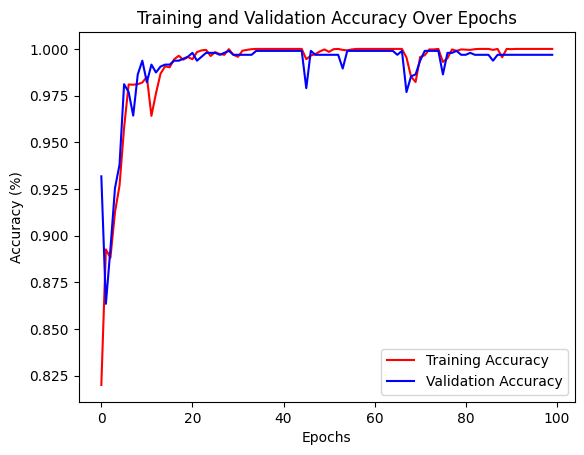

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step
Results for /content/RPLA13A_test_CORRECTED.csv:
Validation Accuracy: 99.68%
Test Accuracy: 98.66%
Test Precision: 1.00
Test Sensitivity: 0.98
Test F1 Score: 0.99
---
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step
Results for /content/NEB_test_test_CORRECTED.csv:
Validation Accuracy: 99.68%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 40s 168ms/step
Results for /content/TTN_test_CORRECTED.csv:
Validation Accuracy: 99.68%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                   File  Validation ACC  Validation PRE  \
0   /content/RPLA13A_test_CORRECTED.csv       99.684874             1.0   
1  /content/NEB_test_test_CORRECTED.csv       99.684874             1.0   
2       /content/TTN_test_CO

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/RPLA13A_test_CORRECTED.csv",
  "/content/NEB_test_test_CORRECTED.csv",
  "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)


# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 789ms/step - accuracy: 0.5964 - loss: 0.6877 - val_accuracy: 0.7045 - val_loss: 0.6515
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 805ms/step - accuracy: 0.7059 - loss: 0.6348 - val_accuracy: 0.7045 - val_loss: 0.6063
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 898ms/step - accuracy: 0.7086 - loss: 0.5955 - val_accuracy: 0.7045 - val_loss: 0.6019
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 723ms/step - accuracy: 0.7172 - loss: 0.5669 - val_accuracy: 0.7045 - val_loss: 0.5797
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 911ms/step - accuracy: 0.7291 - loss: 0.5590 - val_accuracy: 0.7273 - val_loss: 0.5323
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 898ms/step - accuracy: 0.7035 - loss: 0.5532 - val_accuracy: 0.7500 - val_loss: 0.4673
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 867ms/step - accuracy: 0.7515 - loss: 0.4748 - val_accuracy: 0.7955 - val_loss: 0.4372
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 909ms/step - accuracy: 0.8036 - loss: 0.4731 - val_accuracy

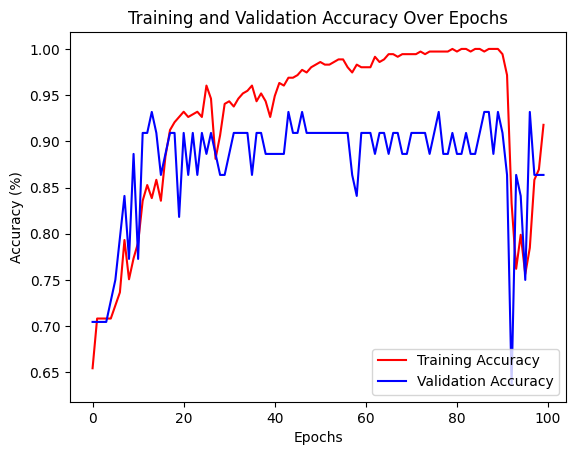

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
Results for /content/ANKRD1_test_CORRECTED.csv:
Validation Accuracy: 86.36%
Test Accuracy: 94.12%
Test Precision: 0.90
Test Sensitivity: 1.00
Test F1 Score: 0.95
---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 86.36%
Test Accuracy: 94.12%
Test Precision: 0.97
Test Sensitivity: 0.93
Test F1 Score: 0.95
---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
Results for /content/PPIAFIX2_test_CORRECTED.csv:
Validation Accuracy: 86.36%
Test Accuracy: 83.80%
Test Precision: 0.94
Test Sensitivity: 0.76
Test F1 Score: 0.84
---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step
Results for /content/GADPH_test_CORRECTED.csv:
Validation Accuracy: 86.36%
Test Accuracy: 97.28%
Test Precision: 0.99
Test Sensitivity: 0.96
Test F1 Score: 0.97
---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step
Results for /content/PGK1_test_CORRECTED.csv:
Validation Accuracy: 86.36%
Test Accuracy: 83.82%
Test Precision: 0.84
Test Sensitivity: 0.86
Test F1 Score: 0.85
---
                                   File  Validation ACC  Validat

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [
  "/content/ANKRD1_test_CORRECTED.csv",
  "/content/B2MFIX_test_CORRECTED.csv",
  "/content/PPIAFIX2_test_CORRECTED.csv",
  "/content/GADPH_test_CORRECTED.csv",
  "/content/PGK1_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6154 - loss: 0.6930 - val_accuracy: 1.0000 - val_loss: 0.6903
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7692 - loss: 0.6912 - val_accuracy: 1.0000 - val_loss: 0.6891
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7692 - loss: 0.6883 - val_accuracy: 1.0000 - val_loss: 0.6858
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step - accuracy: 0.7692 - loss: 0.6884 - val_accuracy: 1.0000 - val_loss: 0.6804
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7692 - loss: 0.6815 - val_accuracy: 1.0000 - val_loss: 0.6736
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step - accuracy: 0.7692 - loss: 0.6793 - val_accuracy: 1.0000 - val_loss: 0.6637
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step - accuracy: 0.7692 - loss: 0.6774 - val_accuracy: 1.0000 - val_loss: 0.6532
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step - accuracy: 0.7692 - loss: 0.6713 - val_accuracy: 1.0000 - val_loss: 0.6387
Epoch 9/

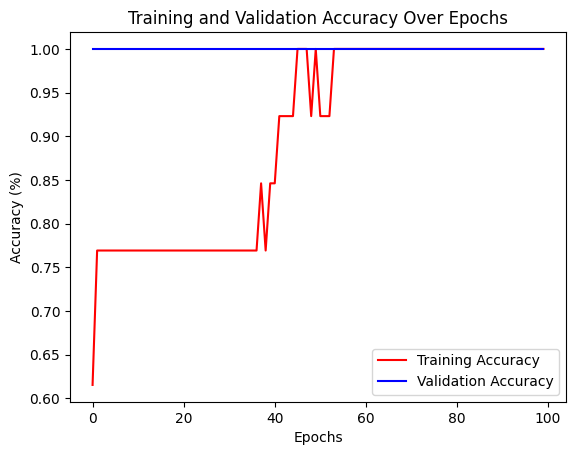

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
Results for /content/ANKRD1_test_CORRECTED.csv:
Validation Accuracy: 100.00%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                 File  Validation ACC  Validation PRE  \
0  /content/ANKRD1_test_CORRECTED.csv           100.0             1.0   

   Validation SEN  Validation F1S  Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0     100.0       1.0       1.0       1.0  
Results with Total Metrics:
                                 File  Validation ACC  Validation PRE  \
0  /content/ANKRD1_test_CORRECTED.csv           100.0             1.0   
1                               Total           100.0             1.0   

   Validation SEN  Validation F1S  Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0     100.0       1.0       1.0       1.0  
1             1.0             1.0     100.0       1.0  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [
  "/content/ANKRD1_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7581 - loss: 0.6854 - val_accuracy: 1.0000 - val_loss: 0.6624
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 793ms/step - accuracy: 0.8966 - loss: 0.6659 - val_accuracy: 1.0000 - val_loss: 0.6271
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 796ms/step - accuracy: 0.8738 - loss: 0.6360 - val_accuracy: 1.0000 - val_loss: 0.5759
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9231 - loss: 0.5916 - val_accuracy: 1.0000 - val_loss: 0.5075
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9231 - loss: 0.5333 - val_accuracy: 1.0000 - val_loss: 0.4264
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 795ms/step - accuracy: 0.8966 - loss: 0.4756 - val_accuracy: 1.0000 - val_loss: 0.3441
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 846ms/step - accuracy: 0.9231 - loss: 0.3929 - val_accuracy: 1.0000 - val_loss: 0.2645
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 828ms/step - accuracy: 0.9231 - loss: 0.3395 - val_accuracy: 1.0000 - val_loss: 0.1928
Epoc

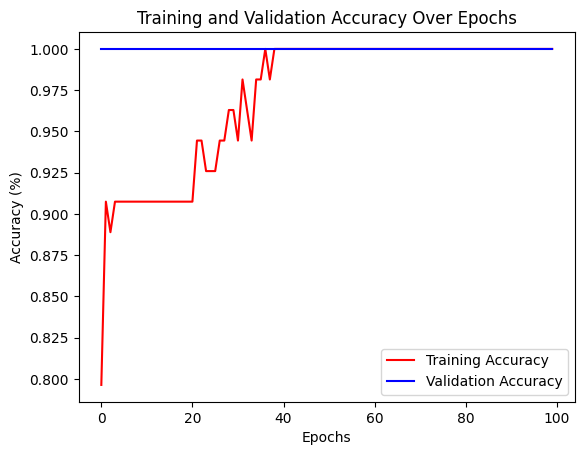

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step
Results for /content/B2MFIX_test_CORRECTED.csv:
Validation Accuracy: 100.00%
Test Accuracy: 100.00%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                 File  Validation ACC  Validation PRE  \
0  /content/B2MFIX_test_CORRECTED.csv           100.0             1.0   

   Validation SEN  Validation F1S  Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0     100.0       1.0       1.0       1.0  
Results with Total Metrics:
                                 File  Validation ACC  Validation PRE  \
0  /content/B2MFIX_test_CORRECTED.csv           100.0             1.0   
1                               Total           100.0             1.0   

   Validation SEN  Validation F1S  Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0     100.0       1.0       1.0       1.0  
1             1.0             1.0     100.0       1.0       1.0       1.0  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/B2MFIX_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/PPIAFIX2_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/GADPH_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/PGK1_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/RPLA13A_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 864ms/step - accuracy: 0.7672 - loss: 0.5689 - val_accuracy: 0.8323 - val_loss: 0.3998
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 836ms/step - accuracy: 0.8559 - loss: 0.3736 - val_accuracy: 0.8383 - val_loss: 0.2639
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 838ms/step - accuracy: 0.8915 - loss: 0.2673 - val_accuracy: 0.9162 - val_loss: 0.2042
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 839ms/step - accuracy: 0.9325 - loss: 0.1808 - val_accuracy: 0.9461 - val_loss: 0.1627
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 885ms/step - accuracy: 0.9505 - loss: 0.1468 - val_accuracy: 0.9102 - val_loss: 0.2184
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 890ms/step - accuracy: 0.9490 - loss: 0.1323 - val_accuracy: 0.9581 - val_loss: 0.1205
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 841ms/step - accuracy: 0.9716 - loss: 0.0968 - val_accuracy: 0.9641 - val_loss: 0.1143
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 837ms/step - accuracy: 0.9745 - loss: 0.0749 - val_accuracy

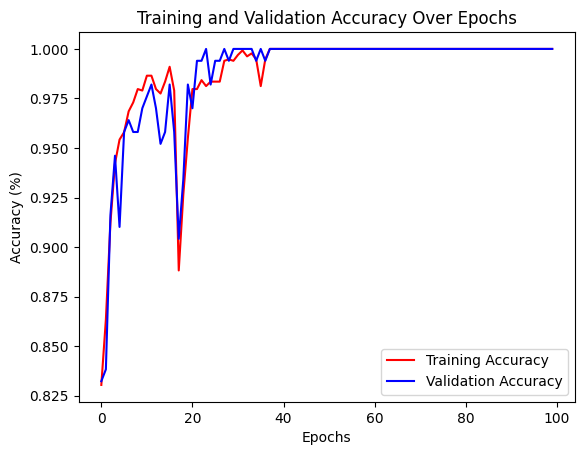

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step
Results for /content/NEB_test_test_CORRECTED.csv:
Validation Accuracy: 100.00%
Test Accuracy: 99.94%
Test Precision: 1.00
Test Sensitivity: 1.00
Test F1 Score: 1.00
---
                                   File  Validation ACC  Validation PRE  \
0  /content/NEB_test_test_CORRECTED.csv           100.0             1.0   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0  99.940012       1.0  0.998815  0.999407  
Results with Total Metrics:
                                   File  Validation ACC  Validation PRE  \
0  /content/NEB_test_test_CORRECTED.csv           100.0             1.0   
1                                 Total           100.0             1.0   

   Validation SEN  Validation F1S   Test ACC  Test PRE  Test SEN  Test F1S  
0             1.0             1.0  99.940012       1.0  0.998815  0.999407  
1             1.0             1.0  99

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [

  "/content/NEB_test_test_CORRECTED.csv",

]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [
  "/content/TTN_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


191/191 ━━━━━━━━━━━━━━━━━━━━ 174s 867ms/step - accuracy: 0.8073 - loss: 0.4162 - val_accuracy: 0.9803 - val_loss: 0.0617
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 201s 857ms/step - accuracy: 0.9395 - loss: 0.1662 - val_accuracy: 0.8820 - val_loss: 0.3043
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 164s 859ms/step - accuracy: 0.8372 - loss: 0.3490 - val_accuracy: 0.9371 - val_loss: 0.1382
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 202s 860ms/step - accuracy: 0.9665 - loss: 0.0950 - val_accuracy: 0.9974 - val_loss: 0.0186
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 201s 858ms/step - accuracy: 0.9913 - loss: 0.0328 - val_accuracy: 0.9948 - val_loss: 0.0225
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 201s 854ms/step - accuracy: 0.9773 - loss: 0.0688 - val_accuracy: 0.9987 - val_loss: 0.0087
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 202s 853ms/step - accuracy: 0.9908 - loss: 0.0297 - val_accuracy: 0.9987 - val_loss: 0.0085
Epoch 8/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 166s 868ms/step - accuracy: 0.9877 - los

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Parameters
chunk_size = 1000
max_len_limit = 500  # Limit the maximum length of sequences
batch_size = 32  # Adjust batch size if needed
epochs = 100  # Adjust the number of epochs if needed
random_state = 42  # Seed for reproducibility

# File paths
# Caminhos dos arquivos
file_paths = [
  "/content/TTN_test_CORRECTED.csv",
  "/content/NEB_test_test_CORRECTED.csv",
]

# 1. Function to process chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# 2. Tokenization of sequences
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Process CSV files in chunks for training
for file_path in file_paths:
    chunks = pd.read_csv(file_path, chunksize=chunk_size)
    for chunk in chunks:
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenize and pad sequences
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')

# Convert labels to numpy array (adjust label type if necessary)
labels = np.array(labels_list, dtype=np.int8)

# 3. Split into train, validation, and test sets (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# 4. Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1  # Adiciona espaço para o índice de padding
embedding_dim = 32  # Pode ser ajustado

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),  # Adiciona dropout após a primeira camada LSTM
    Bidirectional(LSTM(32)),
    Dropout(0.2),  # Adiciona dropout após a segunda camada LSTM
    Dense(64, activation='relu'),  # Camada densa com 64 neurônios
    Dense(1, activation='sigmoid')  # Para classificação binária
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Data Generator Class
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_sequences = self.sequences[batch_indexes]
        batch_labels = self.labels[batch_indexes]
        return batch_sequences, batch_labels

# Create the data generators
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# 6. Train the model and collect history
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# 7. Plotting the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')

# Personalize the graph
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')

# Show the graph
plt.show()

# 8. Evaluation functions to calculate metrics
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# 9. Initialize dictionary to store results
results = {
    "File": [],
    "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": [],
}

# 10. Evaluate the model on each file for validation and test
for test_file in file_paths:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenize and pad test sequences
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Evaluate validation data
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Evaluate test data
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Store results for current file
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test F1 Score: {test_f1_score:.2f}')
    print('---')

# 11. Display all results
results_df = pd.DataFrame(results)
print(results_df)

# 12. Calculate and print total averages
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Add total metrics to the results DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test F1S": [total_avg["Test F1S"]],
})

# Concatenate the total metrics row to the results dataframe
results_df = pd.concat([results_df, total_metrics], ignore_index=True)

# Print the final results with total metrics
print("Results with Total Metrics:")
print(results_df)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

# Modelo Bidirectional LSTM com RMSprop
model_rmsprop = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='sigmoid'),
    Dense(1, activation='sigmoid')
])

# Compilar o modelo com RMSprop
model_rmsprop.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento com RMSprop
history_rmsprop = model_rmsprop.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Plotar histórico do modelo RMSprop
plot_history(history_rmsprop)


# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e armazenamento do histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)


# Plotando o histórico de treinamento
plot_history(history)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 10
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

# Construção do modelo Bidirectional LSTM com Adam
model_adam = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model_adam.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

history = model_adam.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para plotar gráficos de perda
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    f1 = f1_score(y_true, predictions)
    return accuracy, precision, sensitivity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_accuracy, val_precision, val_sensitivity, val_f1 = evaluate_model(validation_generator, y_val)

    # Avaliação nos dados de teste
    test_predictions = model.predict(padded_test_sequences)
    test_predictions = (test_predictions > 0.5).astype(int)
    test_accuracy = accuracy_score(test_labels, test_predictions)
    test_precision = precision_score(test_labels, test_predictions)
    test_sensitivity = recall_score(test_labels, test_predictions)
    test_f1_score = f1_score(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test F1S"].append(test_f1_score)

    # Plotando a matriz de confusão para os dados de teste
    conf_matrix = confusion_matrix(test_labels, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Intron', 'Exon'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {test_file}')
    plt.show()

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)


# Plotando o histórico de treinamento
plot_history(history)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 676s 1s/step - accuracy: 0.8273 - loss: 0.3760 - val_accuracy: 0.9458 - val_loss: 0.1728
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 474s 892ms/step - accuracy: 0.9175 - loss: 0.2143 - val_accuracy: 0.9468 - val_loss: 0.1391
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 451s 904ms/step - accuracy: 0.9510 - loss: 0.1223 - val_accuracy: 0.9829 - val_loss: 0.0787
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 374s 749ms/step - accuracy: 0.9774 - loss: 0.0788 - val_accuracy: 0.9859 - val_loss: 0.0430
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 374s 750ms/step - accuracy: 0.9873 - loss: 0.0453 - val_accuracy: 0.9890 - val_loss: 0.0343
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 378s 757ms/step - accuracy: 0.9909 - loss: 0.0331 - val_accuracy: 0.9910 - val_loss: 0.0405
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 374s 750ms/step - accuracy: 0.9914 - loss: 0.0303 - val_accuracy: 0.9970 - val_loss: 0.0210
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 384s 754ms/step - accuracy: 0.9921 - loss: 0.0269 

NameError: name 'model' is not defined

In [ ]:
!nohup python script.py &


nohup: appending output to 'nohup.out'


Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 389s 748ms/step - accuracy: 0.8086 - loss: 0.4130 - val_accuracy: 0.9116 - val_loss: 0.2108
Epoch 2/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 323s 647ms/step - accuracy: 0.9298 - loss: 0.1677 - val_accuracy: 0.9167 - val_loss: 0.2295
Epoch 3/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 375s 632ms/step - accuracy: 0.9133 - loss: 0.2297 - val_accuracy: 0.9398 - val_loss: 0.1148
Epoch 4/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 323s 635ms/step - accuracy: 0.9562 - loss: 0.1104 - val_accuracy: 0.9809 - val_loss: 0.0468
Epoch 5/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 320s 641ms/step - accuracy: 0.9817 - loss: 0.0602 - val_accuracy: 0.9859 - val_loss: 0.0452
Epoch 6/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 318s 638ms/step - accuracy: 0.9892 - loss: 0.0393 - val_accuracy: 0.9859 - val_loss: 0.0402
Epoch 7/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 318s 637ms/step - accuracy: 0.9905 - loss: 0.0345 - val_accuracy: 0.9869 - val_loss: 0.0298
Epoch 8/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 316s 632ms/step - accuracy: 0.9928 - loss: 0.02

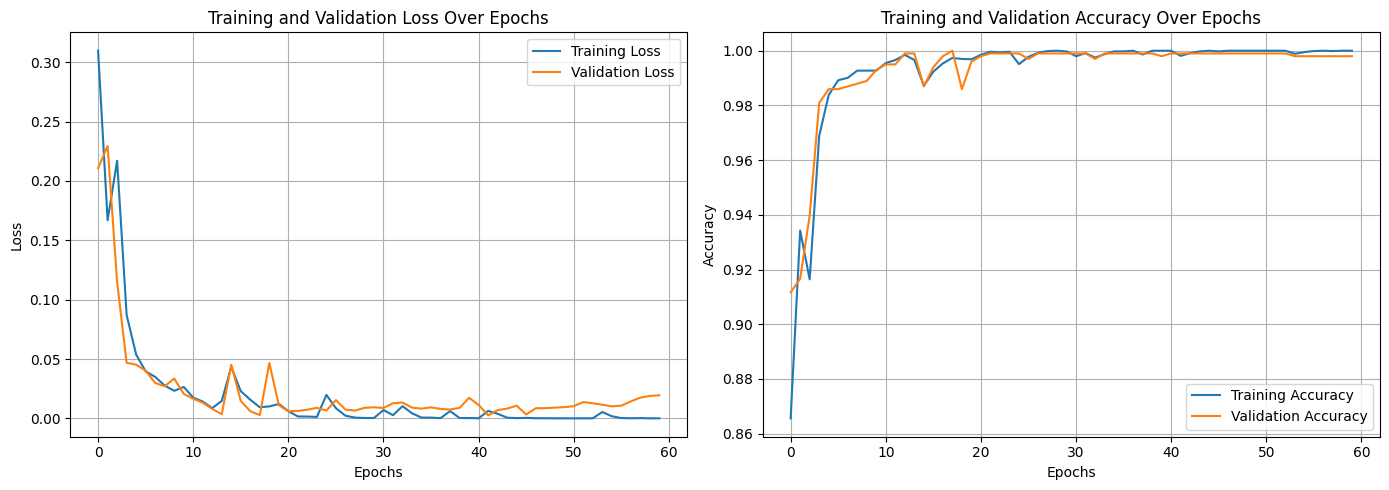

Modelo salvo como lstm_model.h5


ValueError: mount failed

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer apenas uma vez, fora do loop de chunks
tokenizer = Tokenizer(char_level=True)
sequences_list = []  # Inicialização correta das variáveis
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Ajustando o tokenizer apenas após reunir todas as sequências
tokenizer.fit_on_texts(sequences_list)

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação, incluindo especificidade
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # Sensibilidade é o Recall
    f1 = f1_score(y_true, y_pred)

    # Cálculo da especificidade
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation SPEC": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test SPEC": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_predictions = (model.predict(validation_generator) > 0.5).astype(int)
    val_accuracy, val_precision, val_sensitivity, val_specificity, val_f1 = evaluate_model(y_val, val_predictions)

    # Avaliação nos dados de teste
    test_predictions = (model.predict(padded_test_sequences) > 0.5).astype(int)
    test_accuracy, test_precision, test_sensitivity, test_specificity, test_f1 = evaluate_model(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation SPEC"].append(val_specificity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test SPEC"].append(test_specificity)
    results["Test F1S"].append(test_f1)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test Specificity: {test_specificity:.2f}')
    print(f'Test F1 Score: {test_f1:.2f}')
    print('---')

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Calculando as médias totais
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Adicionando as métricas totais ao DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation SPEC": [total_avg["Validation SPEC"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test SPEC": [total_avg["Test SPEC"]],
    "Test F1S": [total_avg["Test F1S"]]
})

# Concatenando as métricas totais ao DataFrame de resultados
results_df = pd.concat([results_df, total_metrics], ignore_index=True)
print("Results with Total Metrics:")
print(results_df)

# Função para plotar gráficos de perda e acurácia
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)

    # Gráfico de Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Chamando a função para plotar os gráficos
plot_history(history)

# Salvando o modelo treinado
model.save("/content/lstm_model.h5")
print("Modelo salvo como lstm_model.h5")

# Montando o Google Drive e copiando o modelo para lá
from google.colab import drive
drive.mount('/content/drive')
!cp /content/lstm_model.h5 /content/drive/MyDrive/lstm_model.h5
print("Modelo salvo no Google Drive como lstm_model.h5")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 2
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer fora do loop de chunks
tokenizer = Tokenizer(char_level=True)
sequences_list, labels_list = [], []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Ajustando o tokenizer após reunir todas as sequências
tokenizer.fit_on_texts(sequences_list)

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))
        super().__init__()

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator, verbose=2)

# Função para calcular métricas de avaliação
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Cálculo da especificidade
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, _, _ = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Proteção contra divisão por zero

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação nos arquivos de treino/validação
results = {"Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation SPEC": [], "Validation F1S": [],
           "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test SPEC": [], "Test F1S": []}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_predictions = (model.predict(validation_generator) > 0.5).astype(int)
    val_accuracy, val_precision, val_sensitivity, val_specificity, val_f1 = evaluate_model(y_val, val_predictions)

    # Avaliação nos dados de teste
    test_predictions = (model.predict(padded_test_sequences) > 0.5).astype(int)
    test_accuracy, test_precision, test_sensitivity, test_specificity, test_f1 = evaluate_model(test_labels, test_predictions)

    # Armazenando os resultados
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation SPEC"].append(val_specificity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test SPEC"].append(test_specificity)
    results["Test F1S"].append(test_f1)

# Exibindo as métricas combinadas
total_avg = {metric: np.mean(values) for metric, values in results.items()}
print("Métricas Totais (combinadas):")
print(f"Validation Accuracy: {total_avg['Validation ACC']:.2f}%")
print(f"Test Accuracy: {total_avg['Test ACC']:.2f}%")
print(f"Test Precision: {total_avg['Test PRE']:.2f}")
print(f"Test Sensitivity: {total_avg['Test SEN']:.2f}")
print(f"Test Specificity: {total_avg['Test SPEC']:.2f}")
print(f"Test F1 Score: {total_avg['Test F1S']:.2f}")

# Salvando o modelo treinado
model.save("/content/finalModelBILSTM.h5")
print("Modelo salvo como finalModelBILSTM.h5")

# Montando o Google Drive e copiando o modelo para lá
from google.colab import drive
drive.mount('/content/drive')
!cp /content/finalModelBILSTM.h5 /content/drive/MyDrive/finalModelBILSTM.h5
print("Modelo salvo no Google Drive como finalModelBILSTM.h5")


Epoch 1/2
499/499 - 524s - 1s/step - accuracy: 0.8689 - loss: 0.3324 - val_accuracy: 0.9528 - val_loss: 0.1544
Epoch 2/2
499/499 - 449s - 900ms/step - accuracy: 0.9112 - loss: 0.2284 - val_accuracy: 0.9036 - val_loss: 0.3008
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step


Métricas Totais (combinadas):
Validation Accuracy: 90.36%
Test Accuracy: 79.70%
Test Precision: 1.00
Test Sensitivity: 0.63
Test Specificity: 1.00
Test F1 Score: 0.76
Modelo salvo como finalModelBILSTM.h5
Mounted at /content/drive
Modelo salvo no Google Drive como finalModelBILSTM.h5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 515s 992ms/step - accuracy: 0.8389 - loss: 0.3685 - val_accuracy: 0.9629 - val_loss: 0.1071


63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 198ms/step
Test Accuracy: 95.19%
Test Precision: 0.95
Test Sensitivity (Recall): 0.96
Test Specificity: 0.47
Test F1 Score: 0.95


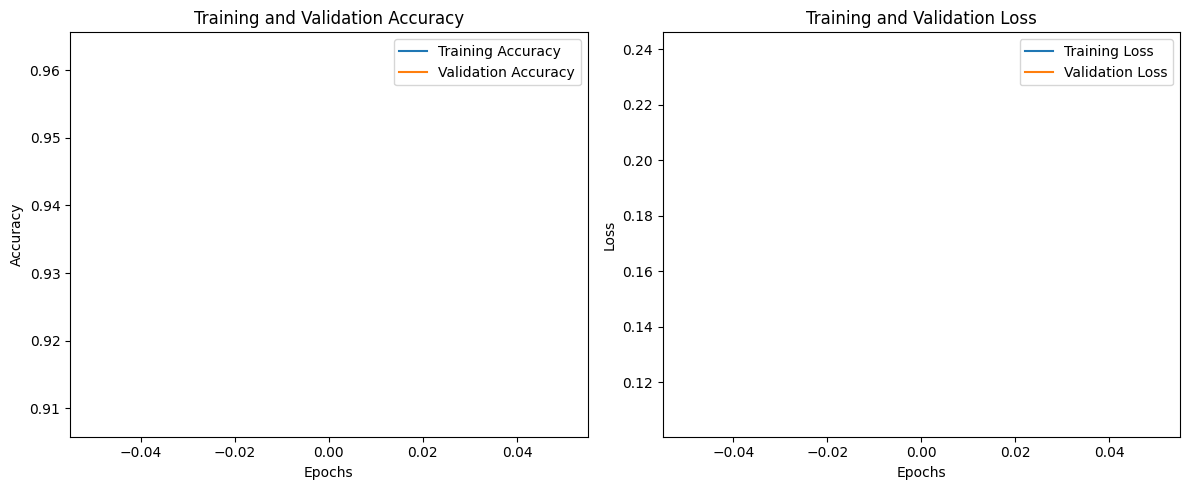

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 1
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com LSTM bidirecional
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo e salvando o histórico
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Salvando o modelo no Google Drive
model.save('/content/drive/MyDrive/GRAPHSmeu_modelo_lstm_bidirecional20EPOCHS.h5')

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)
    tn = np.sum((y_true == 0) & (predictions == 0))
    fp = np.sum((y_true == 0) & (predictions == 1))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, predictions)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1 = evaluate_model(test_generator, y_test)

# Exibindo métricas
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Precision: {precision:.2f}')
print(f'Test Sensitivity (Recall): {sensitivity:.2f}')
print(f'Test Specificity: {specificity:.2f}')
print(f'Test F1 Score: {f1:.2f}')

# Plotando acurácia de treino e validação
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Plotando perda de treino e validação
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import Sequence
import gc

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []  # Inicialização correta das variáveis
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        tokenizer.fit_on_texts(sequences)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo RNN com LSTM bidirecional
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),  # LSTM Bidirecional
    Dropout(0.2),
    Bidirectional(LSTM(32)),  # Segunda camada LSTM Bidirecional
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Salvando o modelo no Google Drive
model.save('/content/drive/MyDrive/meu_modelo_lstm_bidirecional60EPOCHS.h5')

# Função para calcular métricas de avaliação
def evaluate_model(generator, y_true):
    predictions = model.predict(generator)
    predictions = (predictions > 0.5).astype(int)

    # Métricas de classificação
    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions)
    sensitivity = recall_score(y_true, predictions)  # Também chamado de recall

    # Cálculo da especificidade
    tn = np.sum((y_true == 0) & (predictions == 0))  # Verdadeiros negativos
    fp = np.sum((y_true == 0) & (predictions == 1))  # Falsos positivos
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # F1-score
    f1 = f1_score(y_true, predictions)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação no conjunto de teste
test_generator = DataGenerator(X_test, y_test, batch_size)
accuracy, precision, sensitivity, specificity, f1 = evaluate_model(test_generator, y_test)

# Exibindo métricas
print(f'Test Accuracy: {accuracy * 100:.2f}%')
print(f'Test Precision: {precision:.2f}')
print(f'Test Sensitivity (Recall): {sensitivity:.2f}')
print(f'Test Specificity: {specificity:.2f}')
print(f'Test F1 Score: {f1:.2f}')


Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 548s 1s/step - accuracy: 0.8070 - loss: 0.4223 - val_accuracy: 0.9639 - val_loss: 0.1025
Epoch 2/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 341s 620ms/step - accuracy: 0.9489 - loss: 0.1267 - val_accuracy: 0.9649 - val_loss: 0.1147
Epoch 3/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 317s 611ms/step - accuracy: 0.9619 - loss: 0.1077 - val_accuracy: 0.9217 - val_loss: 0.2096
Epoch 4/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 304s 610ms/step - accuracy: 0.9132 - loss: 0.2088 - val_accuracy: 0.9237 - val_loss: 0.1746
Epoch 5/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 322s 610ms/step - accuracy: 0.9388 - loss: 0.1525 - val_accuracy: 0.9839 - val_loss: 0.0564
Epoch 6/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 326s 617ms/step - accuracy: 0.9683 - loss: 0.0767 - val_accuracy: 0.9859 - val_loss: 0.0432
Epoch 7/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 319s 612ms/step - accuracy: 0.9787 - loss: 0.0566 - val_accuracy: 0.9920 - val_loss: 0.0236
Epoch 8/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 324s 615ms/step - accuracy: 0.9773 - loss: 0.0683 

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step
Test Accuracy: 99.50%
Test Precision: 0.99
Test Sensitivity (Recall): 1.00
Test Specificity: 0.48
Test F1 Score: 1.00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer
tokenizer = Tokenizer(char_level=True)
sequences_list = []
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

tokenizer.fit_on_texts(sequences_list)

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação, incluindo especificidade
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # Sensibilidade é o Recall
    f1 = f1_score(y_true, y_pred)

    # Cálculo da especificidade
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation SPEC": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test SPEC": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_predictions = (model.predict(validation_generator) > 0.5).astype(int)
    val_accuracy, val_precision, val_sensitivity, val_specificity, val_f1 = evaluate_model(y_val, val_predictions)

    # Avaliação nos dados de teste
    test_predictions = (model.predict(padded_test_sequences) > 0.5).astype(int)
    test_accuracy, test_precision, test_sensitivity, test_specificity, test_f1 = evaluate_model(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation SPEC"].append(val_specificity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test SPEC"].append(test_specificity)
    results["Test F1S"].append(test_f1)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test Specificity: {test_specificity:.2f}')
    print(f'Test F1 Score: {test_f1:.2f}')
    print('---')

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Calculando as médias totais
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Adicionando as métricas totais ao DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation SPEC": [total_avg["Validation SPEC"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test SPEC": [total_avg["Test SPEC"]],
    "Test F1S": [total_avg["Test F1S"]]
})

# Concatenando as métricas totais ao DataFrame de resultados
results_df = pd.concat([results_df, total_metrics], ignore_index=True)
print("Results with Total Metrics:")
print(results_df)

# Função para plotar gráficos de perda e acurácia e salvar os gráficos como arquivos PNG
def plot_and_save_history(history):
    # Gráfico de Perda (Loss)
    plt.figure()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig("training_validation_loss.png")
    plt.close()

    # Gráfico de Acurácia
    plt.figure()
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig("training_validation_accuracy.png")
    plt.close()

    print("Gráficos salvos como 'training_validation_loss.png' e 'training_validation_accuracy.png'.")

# Chamando a função para salvar os gráficos
plot_and_save_history(history)

# Salvando o modelo treinado localmente
model.save("lstm_model.h5")
print("Modelo salvo como lstm_model.h5")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/60


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


499/499 ━━━━━━━━━━━━━━━━━━━━ 474s 903ms/step - accuracy: 0.8029 - loss: 0.4474 - val_accuracy: 0.9157 - val_loss: 0.2393
Epoch 2/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 316s 633ms/step - accuracy: 0.8376 - loss: 0.3565 - val_accuracy: 0.9307 - val_loss: 0.2130
Epoch 3/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 336s 662ms/step - accuracy: 0.9140 - loss: 0.2265 - val_accuracy: 0.9618 - val_loss: 0.1142
Epoch 4/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 329s 659ms/step - accuracy: 0.9287 - loss: 0.1870 - val_accuracy: 0.9357 - val_loss: 0.1972
Epoch 5/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 387s 670ms/step - accuracy: 0.9415 - loss: 0.1525 - val_accuracy: 0.9739 - val_loss: 0.0705
Epoch 6/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 365s 636ms/step - accuracy: 0.9573 - loss: 0.1008 - val_accuracy: 0.9639 - val_loss: 0.0745
Epoch 7/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 325s 642ms/step - accuracy: 0.9567 - loss: 0.1152 - val_accuracy: 0.9849 - val_loss: 0.0600
Epoch 8/60
499/499 ━━━━━━━━━━━━━━━━━━━━ 317s 636ms/step - accuracy: 0.9753 - loss: 0.06

Gráficos salvos como 'training_validation_loss.png' e 'training_validation_accuracy.png'.
Modelo salvo como lstm_model.h5


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence
import gc
import matplotlib.pyplot as plt

# Parâmetros
chunk_size = 1000
max_len_limit = 500
batch_size = 16
epochs = 60
random_state = 42

# Caminhos dos arquivos, incluindo o NEB no treinamento
file_paths_train = [
    "/content/ANKRD1_test_CORRECTED.csv",
    "/content/B2MFIX_test_CORRECTED.csv",
    "/content/PPIAFIX2_test_CORRECTED.csv",
    "/content/GADPH_test_CORRECTED.csv",
    "/content/PGK1_test_CORRECTED.csv",
    "/content/RPLA13A_test_CORRECTED.csv",
    "/content/TTN_test_CORRECTED.csv",
    "/content/NEB_test_test_CORRECTED.csv"  # Incluindo NEB no treino
]

# Função para processar chunks
def process_chunk(chunk):
    sequences = chunk['sequence'].values
    labels = chunk['exon_intron_flag'].values
    return sequences, labels

# Inicializando o tokenizer apenas uma vez, fora do loop de chunks
tokenizer = Tokenizer(char_level=True)
sequences_list = []  # Inicialização correta das variáveis
labels_list = []

# Processando os arquivos CSV em chunks para treino (incluindo NEB)
for file_path in file_paths_train:
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        sequences, labels = process_chunk(chunk)
        sequences_list.extend(sequences)
        labels_list.extend(labels)
        gc.collect()

# Ajustando o tokenizer apenas após reunir todas as sequências
tokenizer.fit_on_texts(sequences_list)

# Tokenização e padding das sequências
encoded_sequences = tokenizer.texts_to_sequences(sequences_list)
max_len = min(max(len(seq) for seq in encoded_sequences), max_len_limit)
padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len, padding='post')
labels = np.array(labels_list, dtype=np.int8)

# Separando os dados em treino (80%), validação (10%) e teste (10%)
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, labels, test_size=0.2, random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state)

# Construção do modelo Bidirectional LSTM
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Classe Data Generator
class DataGenerator(Sequence):
    def __init__(self, sequences, labels, batch_size):
        self.sequences = sequences
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.sequences))

    def __len__(self):
        return int(np.ceil(len(self.sequences) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        return self.sequences[batch_indexes], self.labels[batch_indexes]

# Criando os geradores de dados
train_generator = DataGenerator(X_train, y_train, batch_size)
validation_generator = DataGenerator(X_val, y_val, batch_size)

# Treinamento do modelo
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

# Função para calcular métricas de avaliação, incluindo especificidade
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)  # Sensibilidade é o Recall
    f1 = f1_score(y_true, y_pred)

    # Cálculo da especificidade
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    return accuracy, precision, sensitivity, specificity, f1

# Avaliação nos arquivos de treino/validação
results = {
    "File": [], "Validation ACC": [], "Validation PRE": [], "Validation SEN": [], "Validation SPEC": [], "Validation F1S": [],
    "Test ACC": [], "Test PRE": [], "Test SEN": [], "Test SPEC": [], "Test F1S": []
}

for test_file in file_paths_train:
    test_data = pd.read_csv(test_file)
    test_sequences = test_data['sequence'].values
    test_labels = test_data['exon_intron_flag'].values

    # Tokenização e padding das sequências de teste
    encoded_test_sequences = tokenizer.texts_to_sequences(test_sequences)
    padded_test_sequences = pad_sequences(encoded_test_sequences, maxlen=max_len, padding='post')

    # Avaliação nos dados de validação
    val_predictions = (model.predict(validation_generator) > 0.5).astype(int)
    val_accuracy, val_precision, val_sensitivity, val_specificity, val_f1 = evaluate_model(y_val, val_predictions)

    # Avaliação nos dados de teste
    test_predictions = (model.predict(padded_test_sequences) > 0.5).astype(int)
    test_accuracy, test_precision, test_sensitivity, test_specificity, test_f1 = evaluate_model(test_labels, test_predictions)

    # Armazenando os resultados
    results["File"].append(test_file)
    results["Validation ACC"].append(val_accuracy * 100)
    results["Validation PRE"].append(val_precision)
    results["Validation SEN"].append(val_sensitivity)
    results["Validation SPEC"].append(val_specificity)
    results["Validation F1S"].append(val_f1)
    results["Test ACC"].append(test_accuracy * 100)
    results["Test PRE"].append(test_precision)
    results["Test SEN"].append(test_sensitivity)
    results["Test SPEC"].append(test_specificity)
    results["Test F1S"].append(test_f1)

    print(f'Results for {test_file}:')
    print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    print(f'Test Precision: {test_precision:.2f}')
    print(f'Test Sensitivity: {test_sensitivity:.2f}')
    print(f'Test Specificity: {test_specificity:.2f}')
    print(f'Test F1 Score: {test_f1:.2f}')
    print('---')

# Exibindo todos os resultados
results_df = pd.DataFrame(results)
print(results_df)

# Calculando as médias totais
numeric_columns = results_df.select_dtypes(include=[np.number])
total_avg = numeric_columns.mean(axis=0)

# Adicionando as métricas totais ao DataFrame
total_metrics = pd.DataFrame({
    "File": ["Total"],
    "Validation ACC": [total_avg["Validation ACC"]],
    "Validation PRE": [total_avg["Validation PRE"]],
    "Validation SEN": [total_avg["Validation SEN"]],
    "Validation SPEC": [total_avg["Validation SPEC"]],
    "Validation F1S": [total_avg["Validation F1S"]],
    "Test ACC": [total_avg["Test ACC"]],
    "Test PRE": [total_avg["Test PRE"]],
    "Test SEN": [total_avg["Test SEN"]],
    "Test SPEC": [total_avg["Test SPEC"]],
    "Test F1S": [total_avg["Test F1S"]]
})

# Concatenando as métricas totais ao DataFrame de resultados
results_df = pd.concat([results_df, total_metrics], ignore_index=True)
print("Results with Total Metrics:")
print(results_df)

# Função para plotar gráficos de perda e acurácia
def plot_history(history):
    plt.figure(figsize=(14, 5))

    # Gráfico de Perda (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)

    # Gráfico de Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Chamando a função para plotar os gráficos
plot_history(history)

# Salvando o modelo treinado
model.save("/content/lstm_model.h5")
print("Modelo salvo como lstm_model.h5")

# Montando o Google Drive e copiando o modelo para lá
from google.colab import drive
drive.mount('/content/drive')
!cp /content/lstm_model.h5 /content/drive/MyDrive/lstm_model.h5
print("Modelo salvo no Google Drive como lstm_model.h5")
